## Import Python Packages & Setup Environment

In [1]:
# =============================================================================
# 1. ENVIRONMENT AND IMPORT SETUP
# =============================================================================

from __future__ import annotations

import os
import re
import gc
import json
import glob
import shutil
import logging
import warnings
import datetime as dt
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import xarray as xr

import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patheffects as mpe

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.interpolate import RegularGridInterpolator


# -----------------------------------------------------------------------------
# Runtime behavior
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

xr.set_options(
    keep_attrs=True,
    display_style="html",
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


# -----------------------------------------------------------------------------
# Logging
# -----------------------------------------------------------------------------

LOG_FORMAT = "%(asctime)s | %(levelname)-8s | %(message)s"

logging.basicConfig(
    level=logging.INFO,
    format=LOG_FORMAT,
    datefmt="%Y-%m-%d %H:%M:%S",
)

logger = logging.getLogger("onset_cessation_sl")


# -----------------------------------------------------------------------------
# Basic runtime report
# -----------------------------------------------------------------------------

logger.info("Python executable : %s", os.sys.executable)
logger.info("Python version    : %s", os.sys.version.split()[0])
logger.info("xarray version    : %s", xr.__version__)
logger.info("pandas version    : %s", pd.__version__)
logger.info("numpy version     : %s", np.__version__)
logger.info("geopandas version : %s", gpd.__version__)

2026-06-15 15:27:34 | INFO     | Python executable : c:\Users\ymersha\AppData\Local\miniconda3\envs\env_onset\python.exe
2026-06-15 15:27:34 | INFO     | Python version    : 3.12.13
2026-06-15 15:27:34 | INFO     | xarray version    : 2026.4.0
2026-06-15 15:27:34 | INFO     | pandas version    : 3.0.3
2026-06-15 15:27:34 | INFO     | numpy version     : 2.4.6
2026-06-15 15:27:34 | INFO     | geopandas version : 1.1.3


## Set Working Directory

In [2]:
# =============================================================================
# 2. PROJECT ROOT SETUP
# =============================================================================

def find_project_root(
    start: Optional[Union[str, Path]] = None,
    markers: Sequence[str] = ("data", "outputs"),
    env_var: str = "ONSET_PROJECT_ROOT",
) -> Path:
    """
    Find the project root in a portable way.

    Priority:
    1. Environment variable, e.g. ONSET_PROJECT_ROOT
    2. Current working directory if it contains expected project folders
    3. Parent directories containing expected project folders
    4. Current working directory as fallback
    """
    if env_var in os.environ:
        root = Path(os.environ[env_var]).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"{env_var} points to a missing path: {root}")
        return root

    start_path = Path(start or Path.cwd()).expanduser().resolve()

    candidates = [start_path] + list(start_path.parents)

    for candidate in candidates:
        if all((candidate / marker).exists() for marker in markers):
            return candidate

    logger.warning(
        "Could not find a project root using markers %s. "
        "Using current working directory instead: %s",
        markers,
        start_path,
    )
    return start_path


PROJECT_ROOT = find_project_root()

os.chdir(PROJECT_ROOT)

logger.info("Project root      : %s", PROJECT_ROOT)
logger.info("Current directory : %s", Path.cwd())

2026-06-15 15:27:34 | INFO     | Project root      : D:\dashboard_ons_cess_sl
2026-06-15 15:27:34 | INFO     | Current directory : D:\dashboard_ons_cess_sl


## Input File Paths

In [3]:
# =============================================================================
# 3. INPUT CONFIGURATION
# =============================================================================

@dataclass(frozen=True)
class InputConfig:
    """
    Input configuration for CHIRPS observations, CMCC forecast data,
    and spatial boundary data.
    """

    project_root: Path

    chirps_daily_path: Path
    chirps_var: str

    cmcc_dir: Path
    cmcc_file_pattern: str
    cmcc_file_glob: str
    cmcc_var: str

    kenya_shp: Path

    model_name: str
    init_month: int
    init_day: int

    target_country: str
    target_season: str


INPUTS = InputConfig(
    project_root=PROJECT_ROOT,

    chirps_daily_path=PROJECT_ROOT / "data" / "chirps_pr_ke" / "ke_chirps_pr_r25_1993_2025.nc",
    chirps_var="precip",

    cmcc_dir=PROJECT_ROOT / "data" / "seasonal_pr_downloads_ke" / "cmcc",
    cmcc_file_pattern="cmcc_{year}02_d01.nc",
    cmcc_file_glob="cmcc_*02_d01.nc",
    cmcc_var="tp",  # CMCC total precipitation, cumulative, metres

    kenya_shp=PROJECT_ROOT / "data" / "shapefiles" / "ke" / "ken_admin0.shp",

    model_name="CMCC",
    init_month=2,
    init_day=1,

    target_country="Kenya",
    target_season="MAM",
)


def require_file(path: Path, label: str) -> None:
    """Raise a clear error if a required file is missing."""
    if not path.exists():
        raise FileNotFoundError(f"{label} not found:\n  {path}")


def require_dir(path: Path, label: str) -> None:
    """Raise a clear error if a required directory is missing."""
    if not path.exists():
        raise FileNotFoundError(f"{label} not found:\n  {path}")
    if not path.is_dir():
        raise NotADirectoryError(f"{label} is not a directory:\n  {path}")


require_file(INPUTS.chirps_daily_path, "CHIRPS daily NetCDF")
require_dir(INPUTS.cmcc_dir, "CMCC forecast directory")
require_file(INPUTS.kenya_shp, "Kenya shapefile")


logger.info("CHIRPS input       : %s", INPUTS.chirps_daily_path)
logger.info("CHIRPS variable    : %s", INPUTS.chirps_var)
logger.info("CMCC directory     : %s", INPUTS.cmcc_dir)
logger.info("CMCC variable      : %s", INPUTS.cmcc_var)
logger.info("Kenya shapefile    : %s", INPUTS.kenya_shp)
logger.info("Initialization     : %02d-%02d", INPUTS.init_month, INPUTS.init_day)

2026-06-15 15:27:34 | INFO     | CHIRPS input       : D:\dashboard_ons_cess_sl\data\chirps_pr_ke\ke_chirps_pr_r25_1993_2025.nc
2026-06-15 15:27:34 | INFO     | CHIRPS variable    : precip
2026-06-15 15:27:34 | INFO     | CMCC directory     : D:\dashboard_ons_cess_sl\data\seasonal_pr_downloads_ke\cmcc
2026-06-15 15:27:34 | INFO     | CMCC variable      : tp
2026-06-15 15:27:34 | INFO     | Kenya shapefile    : D:\dashboard_ons_cess_sl\data\shapefiles\ke\ken_admin0.shp
2026-06-15 15:27:34 | INFO     | Initialization     : 02-01


## Setup Output Directory & Product Registry

- It creates directories and a registry of products that later stages must write.

In [4]:
# =============================================================================
# 4. OUTPUT CONFIGURATION AND PRODUCT REGISTRY
# =============================================================================

@dataclass(frozen=True)
class OutputConfig:
    """
    Output paths for the operational onset, cessation, and season-length workflow.
    """

    root: Path

    logs: Path
    manifests: Path
    reference: Path
    preprocessed: Path
    calibration_params: Path
    validation_scores: Path
    operational: Path
    diagnostics: Path
    plots: Path
    bulletins: Path

    # CHIRPS reference products
    chirps_daily_cube: Path
    chirps_q_d_cal: Path
    chirps_q_bar: Path
    chirps_c_clim: Path
    chirps_d_s: Path
    chirps_d_e: Path
    chirps_onset: Path
    chirps_cessation: Path
    chirps_sl: Path
    chirps_detection_rate: Path

    # Tercile thresholds
    t33_onset: Path
    t67_onset: Path
    t33_cessation: Path
    t67_cessation: Path
    t33_sl: Path
    t67_sl: Path

    # CMCC preprocessed products
    cmcc_raw_daily: Path
    cmcc_regridded_daily: Path
    cmcc_bc_daily: Path

    # CMCC Dunning products
    cmcc_onset: Path
    cmcc_cessation: Path
    cmcc_sl: Path

    # Forecast probability products
    prob_onset_tercile: Path
    prob_cessation_tercile: Path
    prob_sl_tercile: Path

    # Metadata
    run_manifest: Path
    product_status: Path


OUT_ROOT = PROJECT_ROOT / "outputs" / "cmcc_v1"

OUTPUTS = OutputConfig(
    root=OUT_ROOT,

    logs=OUT_ROOT / "logs",
    manifests=OUT_ROOT / "manifests",
    reference=OUT_ROOT / "reference",
    preprocessed=OUT_ROOT / "preprocessed",
    calibration_params=OUT_ROOT / "calibration_params",
    validation_scores=OUT_ROOT / "validation_scores",
    operational=OUT_ROOT / "operational_2026",
    diagnostics=OUT_ROOT / "diagnostics",
    plots=OUT_ROOT / "plots",
    bulletins=OUT_ROOT / "plots" / "bulletins",

    # CHIRPS reference products
    chirps_daily_cube=OUT_ROOT / "reference" / "CHIRPS_daily_1993_2025_025deg.nc",
    chirps_q_d_cal=OUT_ROOT / "reference" / "CHIRPS_Q_d_cal_1993_2016.nc",
    chirps_q_bar=OUT_ROOT / "reference" / "CHIRPS_Q_bar_cal_1993_2016.nc",
    chirps_c_clim=OUT_ROOT / "reference" / "CHIRPS_C_clim_cal_1993_2016.nc",
    chirps_d_s=OUT_ROOT / "reference" / "CHIRPS_d_s_cal_1993_2016.nc",
    chirps_d_e=OUT_ROOT / "reference" / "CHIRPS_d_e_cal_1993_2016.nc",
    chirps_onset=OUT_ROOT / "reference" / "CHIRPS_onset_doy_1993_2025.nc",
    chirps_cessation=OUT_ROOT / "reference" / "CHIRPS_cessation_doy_1993_2025.nc",
    chirps_sl=OUT_ROOT / "reference" / "CHIRPS_sl_days_1993_2025.nc",
    chirps_detection_rate=OUT_ROOT / "reference" / "CHIRPS_detection_rate_1993_2025.nc",

    # Tercile thresholds
    t33_onset=OUT_ROOT / "calibration_params" / "t33_onset_doy_cal_1993_2016.nc",
    t67_onset=OUT_ROOT / "calibration_params" / "t67_onset_doy_cal_1993_2016.nc",
    t33_cessation=OUT_ROOT / "calibration_params" / "t33_cessation_doy_cal_1993_2016.nc",
    t67_cessation=OUT_ROOT / "calibration_params" / "t67_cessation_doy_cal_1993_2016.nc",
    t33_sl=OUT_ROOT / "calibration_params" / "t33_sl_days_cal_1993_2016.nc",
    t67_sl=OUT_ROOT / "calibration_params" / "t67_sl_days_cal_1993_2016.nc",

    # CMCC preprocessed products
    cmcc_raw_daily=OUT_ROOT / "preprocessed" / "CMCC_raw_daily_1993_2026.nc",
    cmcc_regridded_daily=OUT_ROOT / "preprocessed" / "CMCC_regridded_daily_1993_2026_025deg.nc",
    cmcc_bc_daily=OUT_ROOT / "preprocessed" / "CMCC_bc_daily_1993_2026_025deg.nc",

    # CMCC Dunning products
    cmcc_onset=OUT_ROOT / "operational_2026" / "CMCC_onset_doy_all_members_1993_2026.nc",
    cmcc_cessation=OUT_ROOT / "operational_2026" / "CMCC_cessation_doy_all_members_1993_2026.nc",
    cmcc_sl=OUT_ROOT / "operational_2026" / "CMCC_sl_days_all_members_1993_2026.nc",

    # Forecast probabilities
    prob_onset_tercile=OUT_ROOT / "operational_2026" / "CMCC_prob_onset_tercile_2026.nc",
    prob_cessation_tercile=OUT_ROOT / "operational_2026" / "CMCC_prob_cessation_tercile_2026.nc",
    prob_sl_tercile=OUT_ROOT / "operational_2026" / "CMCC_prob_sl_tercile_2026.nc",

    # Metadata
    run_manifest=OUT_ROOT / "manifests" / "run_manifest.json",
    product_status=OUT_ROOT / "manifests" / "product_status.csv",
)


def make_output_dirs(outputs: OutputConfig) -> None:
    """Create all output directories used by the workflow."""
    dirs = [
        outputs.root,
        outputs.logs,
        outputs.manifests,
        outputs.reference,
        outputs.preprocessed,
        outputs.calibration_params,
        outputs.validation_scores,
        outputs.operational,
        outputs.diagnostics,
        outputs.plots,
        outputs.bulletins,
    ]

    for directory in dirs:
        directory.mkdir(parents=True, exist_ok=True)


make_output_dirs(OUTPUTS)


# Backward-compatible variable names for existing notebook cells.
# These keep old plotting and diagnostic cells from breaking while you refactor.
OUT_DIR = str(OUTPUTS.root)
PLOT_DIR = str(OUTPUTS.plots)
BULLETIN_DIR = str(OUTPUTS.bulletins)
CALIB_DIR = str(OUTPUTS.calibration_params)
VALID_DIR = str(OUTPUTS.validation_scores)

CHIRPS_DAILY_PATH = str(INPUTS.chirps_daily_path)
CHIRPS_VAR = INPUTS.chirps_var
CMCC_DIR = str(INPUTS.cmcc_dir)
CMCC_FILE_PATTERN = INPUTS.cmcc_file_pattern
FILE_GLOB = INPUTS.cmcc_file_glob
CMCC_VAR = INPUTS.cmcc_var
KENYA_SHP = str(INPUTS.kenya_shp)

OUT_Q_D = str(OUTPUTS.chirps_q_d_cal)
OUT_Q_BAR = str(OUTPUTS.chirps_q_bar)
OUT_C_CLIM = str(OUTPUTS.chirps_c_clim)
OUT_D_S = str(OUTPUTS.chirps_d_s)
OUT_D_E = str(OUTPUTS.chirps_d_e)
OUT_CHIRPS_ONSET = str(OUTPUTS.chirps_onset)
OUT_CHIRPS_CESS = str(OUTPUTS.chirps_cessation)
OUT_CHIRPS_SL = str(OUTPUTS.chirps_sl)
OUT_DET_RATE = str(OUTPUTS.chirps_detection_rate)

OUT_T33_ONSET = str(OUTPUTS.t33_onset)
OUT_T67_ONSET = str(OUTPUTS.t67_onset)
OUT_T33_CESS = str(OUTPUTS.t33_cessation)
OUT_T67_CESS = str(OUTPUTS.t67_cessation)
OUT_T33_SL = str(OUTPUTS.t33_sl)
OUT_T67_SL = str(OUTPUTS.t67_sl)

OUT_CMCC_RAW_DAILY = str(OUTPUTS.cmcc_raw_daily)
OUT_CMCC_REGRIDDED_DAILY = str(OUTPUTS.cmcc_regridded_daily)
OUT_CMCC_BC = str(OUTPUTS.cmcc_bc_daily)
OUT_CMCC_ONSET = str(OUTPUTS.cmcc_onset)
OUT_CMCC_CESS = str(OUTPUTS.cmcc_cessation)
OUT_CMCC_SL = str(OUTPUTS.cmcc_sl)


logger.info("Output root        : %s", OUTPUTS.root)
logger.info("Reference outputs  : %s", OUTPUTS.reference)
logger.info("Preprocessed data  : %s", OUTPUTS.preprocessed)
logger.info("Calibration params : %s", OUTPUTS.calibration_params)
logger.info("Validation scores  : %s", OUTPUTS.validation_scores)
logger.info("Operational output : %s", OUTPUTS.operational)
logger.info("Plots              : %s", OUTPUTS.plots)
logger.info("Bulletins          : %s", OUTPUTS.bulletins)

2026-06-15 15:27:34 | INFO     | Output root        : D:\dashboard_ons_cess_sl\outputs\cmcc_v1
2026-06-15 15:27:34 | INFO     | Reference outputs  : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference
2026-06-15 15:27:34 | INFO     | Preprocessed data  : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\preprocessed
2026-06-15 15:27:34 | INFO     | Calibration params : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\calibration_params
2026-06-15 15:27:34 | INFO     | Validation scores  : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\validation_scores
2026-06-15 15:27:34 | INFO     | Operational output : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\operational_2026
2026-06-15 15:27:34 | INFO     | Plots              : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots
2026-06-15 15:27:34 | INFO     | Bulletins          : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots\bulletins


## NETCDF Output Writing Helper

- This fixes the problem where output paths are defined but not consistently written later. 

- Run this helper every time a stage generates a product.

In [45]:
# =============================================================================
# 5. STANDARD NETCDF WRITING HELPERS
# =============================================================================

def default_netcdf_encoding(ds: xr.Dataset, complevel: int = 4) -> Dict[str, Dict]:
    """
    Create safe default compression encoding for NetCDF outputs.
    """
    encoding = {}

    for var_name, da in ds.data_vars.items():
        if np.issubdtype(da.dtype, np.floating):
            encoding[var_name] = {
                "zlib": True,
                "complevel": complevel,
                "dtype": "float32",
                "_FillValue": np.float32(np.nan),
            }
        elif np.issubdtype(da.dtype, np.integer):
            encoding[var_name] = {
                "zlib": True,
                "complevel": complevel,
            }
        else:
            encoding[var_name] = {
                "zlib": True,
                "complevel": complevel,
            }

    return encoding


def add_global_attrs(
    ds: xr.Dataset,
    title: str,
    stage: str,
    source: str,
    extra_attrs: Optional[Dict[str, str]] = None,
) -> xr.Dataset:
    """
    Add standard metadata to each output dataset.
    """
    ds = ds.copy()

    attrs = {
        "title": title,
        "project": "Operational onset, cessation, and season length forecasting",
        "country": INPUTS.target_country,
        "season": INPUTS.target_season,
        "model": INPUTS.model_name,
        "forecast_initialization": f"{INPUTS.init_month:02d}-{INPUTS.init_day:02d}",
        "method": "Dunning et al. cumulative rainfall anomaly method",
        "stage": stage,
        "source": source,
        "created_on": dt.datetime.now(dt.UTC).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "created_by": "onset-cessation-sl operational notebook",
    }

    if extra_attrs:
        attrs.update(extra_attrs)

    ds.attrs.update(attrs)

    return ds


def write_netcdf_product(
    ds: xr.Dataset,
    path: Union[str, Path],
    title: str,
    stage: str,
    source: str,
    extra_attrs: Optional[Dict[str, str]] = None,
    overwrite: bool = True,
) -> Path:
    """
    Write a NetCDF product safely and consistently.

    This function:
    - ensures the output directory exists;
    - adds global metadata;
    - applies compression;
    - writes atomically through a temporary file;
    - returns the written path.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.exists() and not overwrite:
        raise FileExistsError(f"Output already exists and overwrite=False:\n  {path}")

    ds_out = add_global_attrs(
        ds=ds,
        title=title,
        stage=stage,
        source=source,
        extra_attrs=extra_attrs,
    )

    encoding = default_netcdf_encoding(ds_out)

    tmp_path = path.with_suffix(path.suffix + ".tmp")

    if tmp_path.exists():
        tmp_path.unlink()

    ds_out.to_netcdf(tmp_path, encoding=encoding)

    if path.exists():
        path.unlink()

    tmp_path.rename(path)

    logger.info("Wrote NetCDF product: %s", path)

    return path


def product_exists(path: Union[str, Path]) -> bool:
    """Return True if a product path exists and has non-zero size."""
    path = Path(path)
    return path.exists() and path.stat().st_size > 0


def build_product_status(outputs: OutputConfig) -> pd.DataFrame:
    """
    Build a product status table showing which expected outputs exist.
    """
    output_dict = asdict(outputs)

    rows = []

    for name, value in output_dict.items():
        if name in {
            "root",
            "logs",
            "manifests",
            "reference",
            "preprocessed",
            "calibration_params",
            "validation_scores",
            "operational",
            "diagnostics",
            "plots",
            "bulletins",
        }:
            continue

        path = Path(value)
        rows.append(
            {
                "product": name,
                "path": str(path),
                "exists": product_exists(path),
                "size_mb": round(path.stat().st_size / 1_000_000, 3) if path.exists() else 0.0,
            }
        )

    return pd.DataFrame(rows)


product_status = build_product_status(OUTPUTS)
product_status.to_csv(OUTPUTS.product_status, index=False)

display(product_status)

logger.info("Product status written to: %s", OUTPUTS.product_status)

,product,path,exists,size_mb
0,chirps_daily_cube,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,True,12.615
1,chirps_q_d_cal,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
2,chirps_q_bar,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
3,chirps_c_clim,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
4,chirps_d_s,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
5,chirps_d_e,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
6,chirps_onset,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
7,chirps_cessation,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
8,chirps_sl,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000
9,chirps_detection_rate,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,0.000


2026-06-16 11:48:38 | INFO     | Product status written to: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\product_status.csv


## Year Splits Definitions

- Effective years will be calculated after scanning CHIRPS and CMCC availability.

In [6]:
# =============================================================================
# 6. INTENDED CALIBRATION, VALIDATION, AND OPERATIONAL YEAR DEFINITIONS
# =============================================================================

CAL_START = 1993
CAL_END = 2016

VAL_START = 2017
VAL_END = 2025

OP_YEAR = 2026

CAL_YEARS_INTENDED = np.arange(CAL_START, CAL_END + 1, dtype=int)
VAL_YEARS_INTENDED = np.arange(VAL_START, VAL_END + 1, dtype=int)
OP_YEARS = np.array([OP_YEAR], dtype=int)

ALL_YEARS_INTENDED = np.concatenate(
    [
        CAL_YEARS_INTENDED,
        VAL_YEARS_INTENDED,
        OP_YEARS,
    ]
)

INIT_MONTH = INPUTS.init_month
INIT_DAY = INPUTS.init_day

logger.info("Intended CAL years : %d-%d (%d years)", CAL_START, CAL_END, len(CAL_YEARS_INTENDED))
logger.info("Intended VAL years : %d-%d (%d years)", VAL_START, VAL_END, len(VAL_YEARS_INTENDED))
logger.info("Operational year   : %d", OP_YEAR)
logger.info("Initialization     : %02d-%02d", INIT_MONTH, INIT_DAY)

2026-06-15 15:27:34 | INFO     | Intended CAL years : 1993-2016 (24 years)
2026-06-15 15:27:34 | INFO     | Intended VAL years : 2017-2025 (9 years)
2026-06-15 15:27:34 | INFO     | Operational year   : 2026
2026-06-15 15:27:34 | INFO     | Initialization     : 02-01


## Input data Inventory
 
 - This cell detects the actual available years.

In [7]:
# =============================================================================
# 7. INPUT DATA INVENTORY
# =============================================================================

def extract_year_from_cmcc_filename(path: Union[str, Path]) -> Optional[int]:
    """
    Extract year from CMCC filename such as cmcc_199302_d01.nc.
    """
    path = Path(path)
    pattern = rf"cmcc_(\d{{4}}){INPUTS.init_month:02d}_d01\.nc$"
    match = re.match(pattern, path.name)

    if match is None:
        return None

    return int(match.group(1))


def discover_cmcc_files(cmcc_dir: Path, file_glob: str) -> Tuple[List[Path], Dict[int, Path]]:
    """
    Discover CMCC files and return:
    - sorted list of files;
    - year-to-file mapping.
    """
    files = sorted(cmcc_dir.glob(file_glob))

    if not files:
        raise FileNotFoundError(
            f"No CMCC files found using pattern '{file_glob}' in:\n  {cmcc_dir}"
        )

    file_map = {}

    for fp in files:
        year = extract_year_from_cmcc_filename(fp)

        if year is None:
            logger.warning("Could not parse CMCC year from filename: %s", fp.name)
            continue

        if year in file_map:
            raise ValueError(
                f"Duplicate CMCC file for year {year}:\n"
                f"  Existing: {file_map[year]}\n"
                f"  New     : {fp}"
            )

        file_map[year] = fp

    if not file_map:
        raise ValueError("CMCC files were found, but no valid years could be parsed.")

    files_valid = [file_map[year] for year in sorted(file_map)]

    return files_valid, file_map


def get_chirps_years(chirps_path: Path) -> np.ndarray:
    """
    Read CHIRPS available years from the time coordinate.
    """
    with xr.open_dataset(chirps_path, decode_times=True) as ds:
        if "time" not in ds.coords:
            raise ValueError("CHIRPS dataset must contain a 'time' coordinate.")

        years = ds["time"].dt.year.values.astype(int)

    return np.unique(years)


all_files, file_map = discover_cmcc_files(
    cmcc_dir=INPUTS.cmcc_dir,
    file_glob=INPUTS.cmcc_file_glob,
)

file_years = np.array(sorted(file_map.keys()), dtype=int)

CHIRPS_AVAILABLE_YEARS = get_chirps_years(INPUTS.chirps_daily_path)
CMCC_AVAILABLE_YEARS = file_years.copy()

expected_cmcc_years = np.arange(
    int(CMCC_AVAILABLE_YEARS.min()),
    int(CMCC_AVAILABLE_YEARS.max()) + 1,
    dtype=int,
)

CMCC_MISSING_YEARS = np.array(
    sorted(set(expected_cmcc_years) - set(CMCC_AVAILABLE_YEARS)),
    dtype=int,
)

logger.info("CMCC files found       : %d", len(all_files))
logger.info("CMCC available years   : %d-%d (%d years)",
            CMCC_AVAILABLE_YEARS.min(), CMCC_AVAILABLE_YEARS.max(), len(CMCC_AVAILABLE_YEARS))
logger.info("CMCC missing years     : %s", CMCC_MISSING_YEARS.tolist() if len(CMCC_MISSING_YEARS) else "None")

logger.info("CHIRPS available years : %d-%d (%d years)",
            CHIRPS_AVAILABLE_YEARS.min(), CHIRPS_AVAILABLE_YEARS.max(), len(CHIRPS_AVAILABLE_YEARS))


inventory_df = pd.DataFrame(
    {
        "year": ALL_YEARS_INTENDED,
        "in_cal_intended": np.isin(ALL_YEARS_INTENDED, CAL_YEARS_INTENDED),
        "in_val_intended": np.isin(ALL_YEARS_INTENDED, VAL_YEARS_INTENDED),
        "is_operational": np.isin(ALL_YEARS_INTENDED, OP_YEARS),
        "chirps_available": np.isin(ALL_YEARS_INTENDED, CHIRPS_AVAILABLE_YEARS),
        "cmcc_available": np.isin(ALL_YEARS_INTENDED, CMCC_AVAILABLE_YEARS),
    }
)

inventory_df["usable_for_cal"] = (
    inventory_df["in_cal_intended"]
    & inventory_df["chirps_available"]
    & inventory_df["cmcc_available"]
)

inventory_df["usable_for_val"] = (
    inventory_df["in_val_intended"]
    & inventory_df["chirps_available"]
    & inventory_df["cmcc_available"]
)

inventory_df["usable_for_op"] = (
    inventory_df["is_operational"]
    & inventory_df["cmcc_available"]
)

inventory_path = OUTPUTS.manifests / "input_year_inventory.csv"
inventory_df.to_csv(inventory_path, index=False)

display(inventory_df)

logger.info("Input year inventory written to: %s", inventory_path)

2026-06-15 15:27:35 | INFO     | CMCC files found       : 33
2026-06-15 15:27:35 | INFO     | CMCC available years   : 1993-2026 (33 years)
2026-06-15 15:27:35 | INFO     | CMCC missing years     : [2025]
2026-06-15 15:27:35 | INFO     | CHIRPS available years : 1993-2025 (33 years)


,year,in_cal_intended,in_val_intended,is_operational,chirps_available,cmcc_available,usable_for_cal,usable_for_val,usable_for_op
0,1993,True,False,False,True,True,True,False,False
1,1994,True,False,False,True,True,True,False,False
2,1995,True,False,False,True,True,True,False,False
3,1996,True,False,False,True,True,True,False,False
4,1997,True,False,False,True,True,True,False,False
5,1998,True,False,False,True,True,True,False,False
6,1999,True,False,False,True,True,True,False,False
7,2000,True,False,False,True,True,True,False,False
8,2001,True,False,False,True,True,True,False,False
9,2002,True,False,False,True,True,True,False,False


2026-06-15 15:27:35 | INFO     | Input year inventory written to: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\input_year_inventory.csv


## Effective Split Calibration, Validation, & Operational Years


- The corrected version that prevents the missing year from being used for validation.

In [8]:
# =============================================================================
# 8. EFFECTIVE CALIBRATION, VALIDATION, AND OPERATIONAL YEARS
# =============================================================================

CAL_YEARS = inventory_df.loc[inventory_df["usable_for_cal"], "year"].to_numpy(dtype=int)
VAL_YEARS = inventory_df.loc[inventory_df["usable_for_val"], "year"].to_numpy(dtype=int)
OP_YEARS_EFFECTIVE = inventory_df.loc[inventory_df["usable_for_op"], "year"].to_numpy(dtype=int)

if len(CAL_YEARS) == 0:
    raise ValueError("No usable calibration years after intersecting CHIRPS and CMCC availability.")

if len(VAL_YEARS) == 0:
    raise ValueError("No usable validation years after intersecting CHIRPS and CMCC availability.")

if OP_YEAR not in OP_YEARS_EFFECTIVE:
    raise FileNotFoundError(
        f"Operational forecast year {OP_YEAR} is not available in CMCC files."
    )

ALL_HINDCAST_YEARS = np.concatenate([CAL_YEARS, VAL_YEARS])
ALL_PROCESSING_YEARS = np.concatenate([ALL_HINDCAST_YEARS, OP_YEARS_EFFECTIVE])

CHIRPS_FULL_YEARS = CHIRPS_AVAILABLE_YEARS.copy()

logger.info("Effective CAL years : %d-%d (%d years)", CAL_YEARS.min(), CAL_YEARS.max(), len(CAL_YEARS))
logger.info("Effective VAL years : %d-%d (%d years)", VAL_YEARS.min(), VAL_YEARS.max(), len(VAL_YEARS))
logger.info("Effective OP years  : %s", OP_YEARS_EFFECTIVE.tolist())
logger.info("All hindcast years  : %d-%d (%d years)",
            ALL_HINDCAST_YEARS.min(), ALL_HINDCAST_YEARS.max(), len(ALL_HINDCAST_YEARS))

if len(CMCC_MISSING_YEARS):
    logger.warning("CMCC missing years detected: %s", CMCC_MISSING_YEARS.tolist())

missing_val_years = sorted(set(VAL_YEARS_INTENDED) - set(VAL_YEARS))

if missing_val_years:
    logger.warning(
        "The following intended validation years are excluded because required data are missing: %s",
        missing_val_years,
    )

2026-06-15 15:27:35 | INFO     | Effective CAL years : 1993-2016 (24 years)
2026-06-15 15:27:35 | INFO     | Effective VAL years : 2017-2024 (8 years)
2026-06-15 15:27:35 | INFO     | Effective OP years  : [2026]
2026-06-15 15:27:35 | INFO     | All hindcast years  : 1993-2024 (32 years)
2026-06-15 15:27:35 | WARNING  | CMCC missing years detected: [2025]
2026-06-15 15:27:35 | WARNING  | The following intended validation years are excluded because required data are missing: [np.int64(2025)]


##  CHIRPS CAL & VAL Split 

In [9]:
# =============================================================================
# 9. CHIRPS CAL/VAL SPLIT
# =============================================================================

def split_chirps_cal_val(
    chirps_path: Path,
    cal_years: Sequence[int],
    val_years: Sequence[int],
) -> Tuple[xr.Dataset, xr.Dataset, xr.Dataset]:
    """
    Open CHIRPS and split into calibration and validation datasets by calendar year.
    """
    ds = xr.open_dataset(chirps_path, decode_times=True)

    if "time" not in ds.coords:
        ds.close()
        raise ValueError("CHIRPS dataset must have a 'time' coordinate.")

    if INPUTS.chirps_var not in ds.data_vars:
        available_vars = list(ds.data_vars)
        ds.close()
        raise KeyError(
            f"CHIRPS variable '{INPUTS.chirps_var}' not found. "
            f"Available variables: {available_vars}"
        )

    years_by_time = ds["time"].dt.year

    cal_mask = years_by_time.isin(list(map(int, cal_years)))
    val_mask = years_by_time.isin(list(map(int, val_years)))

    chirps_cal = ds.where(cal_mask, drop=True)
    chirps_val = ds.where(val_mask, drop=True)

    return ds, chirps_cal, chirps_val


ds_chirps, chirps_cal, chirps_val = split_chirps_cal_val(
    chirps_path=INPUTS.chirps_daily_path,
    cal_years=CAL_YEARS,
    val_years=VAL_YEARS,
)

chirps_time_years = ds_chirps["time"].dt.year.values.astype(int)
chirps_cal_time_years = chirps_cal["time"].dt.year.values.astype(int)
chirps_val_time_years = chirps_val["time"].dt.year.values.astype(int)

chirps_unique_years = np.unique(chirps_time_years)
chirps_cal_unique_years = np.unique(chirps_cal_time_years)
chirps_val_unique_years = np.unique(chirps_val_time_years)

logger.info("CHIRPS file                  : %s", INPUTS.chirps_daily_path)
logger.info("CHIRPS all unique years       : %d-%d (%d years)",
            chirps_unique_years.min(), chirps_unique_years.max(), len(chirps_unique_years))
logger.info("CHIRPS all daily records      : %d", len(chirps_time_years))

logger.info("CHIRPS CAL unique years       : %d-%d (%d years)",
            chirps_cal_unique_years.min(), chirps_cal_unique_years.max(), len(chirps_cal_unique_years))
logger.info("CHIRPS CAL daily records      : %d", len(chirps_cal_time_years))

logger.info("CHIRPS VAL unique years       : %d-%d (%d years)",
            chirps_val_unique_years.min(), chirps_val_unique_years.max(), len(chirps_val_unique_years))
logger.info("CHIRPS VAL daily records      : %d", len(chirps_val_time_years))


chirps_split_summary = pd.DataFrame(
    [
        {
            "period": "all",
            "start_year": int(chirps_unique_years.min()),
            "end_year": int(chirps_unique_years.max()),
            "n_unique_years": int(len(chirps_unique_years)),
            "n_daily_records": int(len(chirps_time_years)),
        },
        {
            "period": "calibration",
            "start_year": int(chirps_cal_unique_years.min()),
            "end_year": int(chirps_cal_unique_years.max()),
            "n_unique_years": int(len(chirps_cal_unique_years)),
            "n_daily_records": int(len(chirps_cal_time_years)),
        },
        {
            "period": "validation",
            "start_year": int(chirps_val_unique_years.min()),
            "end_year": int(chirps_val_unique_years.max()),
            "n_unique_years": int(len(chirps_val_unique_years)),
            "n_daily_records": int(len(chirps_val_time_years)),
        },
    ]
)

split_summary_path = OUTPUTS.manifests / "chirps_cal_val_split_summary.csv"
chirps_split_summary.to_csv(split_summary_path, index=False)

display(chirps_split_summary)

logger.info("CHIRPS split summary written to: %s", split_summary_path)

2026-06-15 15:27:36 | INFO     | CHIRPS file                  : D:\dashboard_ons_cess_sl\data\chirps_pr_ke\ke_chirps_pr_r25_1993_2025.nc
2026-06-15 15:27:36 | INFO     | CHIRPS all unique years       : 1993-2025 (33 years)
2026-06-15 15:27:36 | INFO     | CHIRPS all daily records      : 12053
2026-06-15 15:27:36 | INFO     | CHIRPS CAL unique years       : 1993-2016 (24 years)
2026-06-15 15:27:36 | INFO     | CHIRPS CAL daily records      : 8766
2026-06-15 15:27:36 | INFO     | CHIRPS VAL unique years       : 2017-2024 (8 years)
2026-06-15 15:27:36 | INFO     | CHIRPS VAL daily records      : 2922


,period,start_year,end_year,n_unique_years,n_daily_records
0,all,1993,2025,33,12053
1,calibration,1993,2016,24,8766
2,validation,2017,2024,8,2922


2026-06-15 15:27:36 | INFO     | CHIRPS split summary written to: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\chirps_cal_val_split_summary.csv


## Write Setup Information 

In [10]:
# =============================================================================
# 10. RUN MANIFEST
# =============================================================================

def path_to_str_dict(d: Dict) -> Dict:
    """
    Convert Path values inside a dictionary to strings for JSON writing.
    """
    out = {}

    for key, value in d.items():
        if isinstance(value, Path):
            out[key] = str(value)
        else:
            out[key] = value

    return out


run_manifest = {
    "created_on_utc": dt.datetime.now(dt.UTC).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "project_root": str(PROJECT_ROOT),
    "input_config": path_to_str_dict(asdict(INPUTS)),
    "output_root": str(OUTPUTS.root),
    "calendar": {
        "cal_years_intended": CAL_YEARS_INTENDED.tolist(),
        "val_years_intended": VAL_YEARS_INTENDED.tolist(),
        "op_year": int(OP_YEAR),
        "cal_years_effective": CAL_YEARS.tolist(),
        "val_years_effective": VAL_YEARS.tolist(),
        "op_years_effective": OP_YEARS_EFFECTIVE.tolist(),
        "cmcc_missing_years": CMCC_MISSING_YEARS.tolist(),
    },
    "software": {
        "python": os.sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "xarray": xr.__version__,
        "geopandas": gpd.__version__,
    },
}

with open(OUTPUTS.run_manifest, "w", encoding="utf-8") as f:
    json.dump(run_manifest, f, indent=2)

logger.info("Run manifest written to: %s", OUTPUTS.run_manifest)

2026-06-15 15:27:36 | INFO     | Run manifest written to: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\run_manifest.json


In [11]:
# =============================================================================
# 11. PREPROCESSING CONFIGURATION
# =============================================================================

from IPython.display import display

# Rebuild control
FORCE_REBUILD_PREPROCESSING = False

# Preferred format for large daily cubes
SAVE_DAILY_ZARR = True
SAVE_DAILY_NETCDF_COPY = False

# Regridding method:
# "conservative" if xESMF/ESMF is available, otherwise fallback to bilinear.
REGRID_METHOD = "conservative"

# Dynamic chunks are derived later from the loaded datasets.
DAILY_CHUNKS = None
CHIRPS_MATCHING_CHUNKS = None

# Output paths
OUT_CHIRPS_YEAR_DOY = OUTPUTS.reference / "CHIRPS_daily_year_doy_1993_2025_025deg.nc"

OUT_CHIRPS_MATCHING_DAILY_ZARR = (
    OUTPUTS.reference / "CHIRPS_matching_daily_Feb01_lead001_183_1993_2025.zarr"
)

OUT_CHIRPS_MATCHING_DAILY_NC = (
    OUTPUTS.reference / "CHIRPS_matching_daily_Feb01_lead001_183_1993_2025.nc"
)

OUT_CMCC_RAW_DAILY_ZARR = OUTPUTS.preprocessed / "CMCC_raw_daily_1993_2026.zarr"

OUT_CMCC_REGRIDDED_DAILY_ZARR = (
    OUTPUTS.preprocessed / "CMCC_regridded_daily_1993_2026_025deg.zarr"
)

OUT_KENYA_MASK = OUTPUTS.reference / "kenya_land_mask_025deg.nc"
OUT_CMCC_FILE_INVENTORY = OUTPUTS.manifests / "cmcc_file_inventory.csv"
OUT_CMCC_METADATA = OUTPUTS.manifests / "cmcc_metadata_inventory.csv"
OUT_PREPROCESSING_QA = OUTPUTS.manifests / "preprocessing_qa_checks.csv"
OUT_PREPROCESSING_MANIFEST = OUTPUTS.manifests / "preprocessing_manifest.json"
OUT_PREPROCESSING_PRODUCT_STATUS = OUTPUTS.manifests / "preprocessing_product_status.csv"


# Optional dask
try:
    import dask
    HAS_DASK = True
    logger.info("Dask available      : yes")
except Exception:
    HAS_DASK = False
    logger.warning("Dask not available. Large arrays may load into memory.")


# Optional xESMF
try:
    import xesmf as xe
    HAS_XESMF = True
    logger.info("xESMF available     : yes")
except Exception as e:
    HAS_XESMF = False
    logger.warning("xESMF unavailable. Regridding will fall back to xarray bilinear interpolation.")
    logger.warning("xESMF import message: %s", str(e))


def utc_now_string() -> str:
    """Return timezone-aware UTC timestamp string."""
    return dt.datetime.now(dt.UTC).strftime("%Y-%m-%dT%H:%M:%SZ")


def open_dataset_safely(path: Union[str, Path], decode_times: bool = True) -> xr.Dataset:
    """
    Open a dataset with optional dask support.
    """
    path = Path(path)

    if HAS_DASK:
        return xr.open_dataset(path, decode_times=decode_times, chunks={})

    return xr.open_dataset(path, decode_times=decode_times)


def write_zarr_product(
    ds: xr.Dataset,
    path: Union[str, Path],
    title: str,
    stage: str,
    source: str,
    chunks: Optional[Dict[str, int]] = None,
    extra_attrs: Optional[Dict[str, str]] = None,
    overwrite: bool = True,
) -> Path:
    """
    Write a Zarr product with standard metadata and optional dynamic chunks.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.exists() and overwrite:
        shutil.rmtree(path)

    if path.exists() and not overwrite:
        raise FileExistsError(f"Zarr product already exists and overwrite=False:\n  {path}")

    ds_out = add_global_attrs(
        ds=ds,
        title=title,
        stage=stage,
        source=source,
        extra_attrs=extra_attrs,
    )

    if chunks is not None and HAS_DASK:
        valid_chunks = {k: int(v) for k, v in chunks.items() if k in ds_out.dims}
        ds_out = ds_out.chunk(valid_chunks)

    ds_out.to_zarr(path, mode="w", consolidated=True)

    logger.info("Wrote Zarr product: %s", path)

    return path


def maybe_write_daily_netcdf(
    ds: xr.Dataset,
    path: Union[str, Path],
    title: str,
    stage: str,
    source: str,
    extra_attrs: Optional[Dict[str, str]] = None,
) -> Optional[Path]:
    """
    Optionally write NetCDF copy of large daily product.
    """
    if not SAVE_DAILY_NETCDF_COPY:
        logger.info("Skipping NetCDF copy for large daily product: %s", path)
        return None

    return write_netcdf_product(
        ds=ds,
        path=path,
        title=title,
        stage=stage,
        source=source,
        extra_attrs=extra_attrs,
        overwrite=True,
    )

2026-06-15 15:27:36 | INFO     | Dask available      : yes
2026-06-15 15:27:36 | INFO     | xESMF available     : yes


In [16]:
# =============================================================================
# 12. DYNAMIC CHUNKING HELPERS
# =============================================================================

def derive_full_dimension_chunks(
    ds: Union[xr.Dataset, xr.DataArray],
    year_chunk: int = 1,
) -> Dict[str, int]:
    """
    Derive chunk sizes from the actual loaded dataset.

    Policy:
    - year     : 1
    - member   : full member dimension from loaded model
    - lead_day : full lead-day dimension from loaded data
    - lat      : full latitude dimension
    - lon      : full longitude dimension
    - doy      : full day-of-year dimension
    - time     : full time dimension

    This is suitable for Dunning onset/cessation/SL because the full lead season
    and full member distribution are needed together.
    """
    chunks = {}

    for dim, size in ds.sizes.items():
        size = int(size)

        if dim == "year":
            chunks[dim] = min(year_chunk, size)

        elif dim in ["member", "lead_day", "lat", "lon", "doy", "time"]:
            chunks[dim] = size

    return chunks


def log_chunk_plan(
    name: str,
    ds: Union[xr.Dataset, xr.DataArray],
    chunks: Dict[str, int],
    dtype_bytes: int = 4,
) -> None:
    """
    Log the chunking strategy and approximate chunk size.
    """
    chunk_elements = 1

    for dim, chunk_size in chunks.items():
        if dim in ds.sizes:
            chunk_elements *= int(chunk_size)

    approx_mb = chunk_elements * dtype_bytes / 1_000_000

    logger.info("Chunk plan for %s", name)
    logger.info("  dataset dims      : %s", dict(ds.sizes))
    logger.info("  chunk sizes       : %s", chunks)
    logger.info("  approx chunk size : %.2f MB for one float32 variable", approx_mb)


def derive_adaptive_daily_chunks(
    ds: Union[xr.Dataset, xr.DataArray],
    year_chunk: int = 1,
    max_chunk_mb: float = 256.0,
    dtype_bytes: int = 4,
) -> Dict[str, int]:
    """
    Optional adaptive chunking for larger domains.

    For Kenya this is usually not needed, but for East Africa or Africa-wide
    products it can prevent very large chunks.
    """
    sizes = dict(ds.sizes)

    chunks = {}

    if "year" in sizes:
        chunks["year"] = min(year_chunk, int(sizes["year"]))

    if "member" in sizes:
        chunks["member"] = int(sizes["member"])

    if "lead_day" in sizes:
        chunks["lead_day"] = int(sizes["lead_day"])

    if "doy" in sizes:
        chunks["doy"] = int(sizes["doy"])

    if "lat" in sizes:
        chunks["lat"] = int(sizes["lat"])

    if "lon" in sizes:
        chunks["lon"] = int(sizes["lon"])

    def estimate_mb(ch):
        elements = 1
        for d, c in ch.items():
            if d in sizes:
                elements *= int(c)
        return elements * dtype_bytes / 1_000_000

    while estimate_mb(chunks) > max_chunk_mb:
        if "lat" in chunks and chunks["lat"] > 64:
            chunks["lat"] = max(64, chunks["lat"] // 2)

        elif "lon" in chunks and chunks["lon"] > 64:
            chunks["lon"] = max(64, chunks["lon"] // 2)

        elif "member" in chunks and chunks["member"] > 25:
            chunks["member"] = max(25, chunks["member"] // 2)

        else:
            break

    return chunks

In [17]:
# =============================================================================
# 13. COORDINATE, UNIT, AND CALENDAR HELPERS
# =============================================================================

def rename_lat_lon(ds_or_da: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Rename common latitude/longitude names to lat/lon.
    """
    rename_map = {}

    if "latitude" in ds_or_da.coords or "latitude" in ds_or_da.dims:
        rename_map["latitude"] = "lat"

    if "longitude" in ds_or_da.coords or "longitude" in ds_or_da.dims:
        rename_map["longitude"] = "lon"

    if rename_map:
        ds_or_da = ds_or_da.rename(rename_map)

    return ds_or_da


def ensure_increasing_lat_lon(ds_or_da: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Ensure latitude and longitude are increasing.
    """
    ds_or_da = rename_lat_lon(ds_or_da)

    if "lat" in ds_or_da.coords:
        lat_vals = ds_or_da["lat"].values
        if len(lat_vals) > 1 and lat_vals[0] > lat_vals[-1]:
            ds_or_da = ds_or_da.sortby("lat")

    if "lon" in ds_or_da.coords:
        lon_vals = ds_or_da["lon"].values
        if len(lon_vals) > 1 and lon_vals[0] > lon_vals[-1]:
            ds_or_da = ds_or_da.sortby("lon")

    return ds_or_da


def convert_precip_to_mm_day(da: xr.DataArray, source_name: str = "precipitation") -> xr.DataArray:
    """
    Convert daily precipitation to mm/day where possible.
    """
    units = str(da.attrs.get("units", "")).lower().replace(" ", "")

    out = da.copy()

    if units in ["mm", "mm/day", "mmday-1", "mmd-1", "millimeter", "millimeters"]:
        pass

    elif units in ["kgm-2s-1", "kg/m2/s", "kgm**-2s**-1"]:
        out = out * 86400.0
        out.attrs["unit_conversion"] = "Converted from kg m-2 s-1 to mm/day using 86400."

    elif units in ["m", "meter", "metre", "meters", "metres"]:
        out = out * 1000.0
        out.attrs["unit_conversion"] = "Converted from metres to mm."

    else:
        logger.warning(
            "Unknown precipitation units for %s: '%s'. Assuming values are already mm/day.",
            source_name,
            da.attrs.get("units", "missing"),
        )

    out.attrs["units"] = "mm/day"
    out.attrs["long_name"] = "Daily precipitation"

    return out


def lead_coord_to_days(coord: xr.DataArray, init_date: pd.Timestamp) -> np.ndarray:
    """
    Convert CMCC lead/forecast_period coordinate to integer lead days.
    """
    values = coord.values

    if np.issubdtype(values.dtype, np.timedelta64):
        days = values / np.timedelta64(1, "D")
        return np.rint(days).astype(int)

    if np.issubdtype(values.dtype, np.datetime64):
        dates = pd.to_datetime(values)
        days = (dates - init_date).days
        return np.asarray(days, dtype=int)

    values_float = np.asarray(values, dtype=float)
    units = str(coord.attrs.get("units", "")).lower()

    if "hour" in units:
        days = values_float / 24.0

    elif "day" in units:
        days = values_float

    else:
        diffs = np.diff(values_float)
        if len(diffs) > 0 and np.nanmedian(diffs) >= 20:
            days = values_float / 24.0
        else:
            days = values_float

    return np.rint(days).astype(int)


def make_valid_time_and_doy(year: int, lead_days: Sequence[int]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build valid_time and valid_doy arrays from initialization date and lead days.
    """
    init_date = pd.Timestamp(year=int(year), month=INIT_MONTH, day=INIT_DAY)

    valid_times = np.array(
        [init_date + pd.Timedelta(days=int(ld)) for ld in lead_days],
        dtype="datetime64[ns]",
    )

    valid_doy = np.array(
        [pd.Timestamp(t).dayofyear for t in valid_times],
        dtype=np.int16,
    )

    return valid_times, valid_doy

## CHIRPS DAILY INGESTION AND KENYA MASK

In [18]:
# =============================================================================
# 14. CHIRPS DAILY INGESTION AND KENYA MASK
# =============================================================================

logger.info("Loading CHIRPS daily observations")

ds_chirps_src = open_dataset_safely(INPUTS.chirps_daily_path, decode_times=True)
ds_chirps_src = ensure_increasing_lat_lon(ds_chirps_src)

if INPUTS.chirps_var not in ds_chirps_src.data_vars:
    raise KeyError(
        f"CHIRPS variable '{INPUTS.chirps_var}' not found. "
        f"Available variables: {list(ds_chirps_src.data_vars)}"
    )

chirps_pr = ds_chirps_src[INPUTS.chirps_var]
chirps_pr = rename_lat_lon(chirps_pr)
chirps_pr = ensure_increasing_lat_lon(chirps_pr)
chirps_pr = convert_precip_to_mm_day(chirps_pr, source_name="CHIRPS")

chirps_pr.name = "pr"
chirps_pr.attrs.update(
    {
        "standard_name": "precipitation_amount",
        "long_name": "CHIRPS daily precipitation",
        "units": "mm/day",
        "source_dataset": "CHIRPS v2.0",
    }
)

if "time" not in chirps_pr.dims:
    raise ValueError("CHIRPS daily precipitation must have a time dimension.")

target_lat = chirps_pr["lat"].values
target_lon = chirps_pr["lon"].values

CHIRPS_FULL_YEARS = np.unique(chirps_pr["time"].dt.year.values.astype(int))

logger.info("CHIRPS years        : %d-%d (%d years)",
            CHIRPS_FULL_YEARS.min(), CHIRPS_FULL_YEARS.max(), len(CHIRPS_FULL_YEARS))
logger.info("CHIRPS grid         : %d lat x %d lon", len(target_lat), len(target_lon))


def make_country_mask_from_shapefile(
    lat: np.ndarray,
    lon: np.ndarray,
    shp_path: Union[str, Path],
    mask_name: str = "kenya_land_mask",
) -> xr.DataArray:
    """
    Build a country mask on a regular lat/lon grid using a shapefile.
    """
    shp_path = Path(shp_path)

    gdf = gpd.read_file(shp_path)

    if gdf.empty:
        raise ValueError(f"Shapefile is empty: {shp_path}")

    if gdf.crs is None:
        logger.warning("Shapefile CRS missing. Assuming EPSG:4326.")
        gdf = gdf.set_crs("EPSG:4326")

    gdf = gdf.to_crs("EPSG:4326")

    try:
        geom = gdf.geometry.union_all()
    except Exception:
        geom = gdf.geometry.unary_union

    lon2d, lat2d = np.meshgrid(lon, lat)

    try:
        from shapely import contains_xy
        mask = contains_xy(geom.buffer(1e-12), lon2d, lat2d)
    except Exception:
        from shapely.vectorized import contains
        mask = contains(geom.buffer(1e-12), lon2d, lat2d)

    mask_da = xr.DataArray(
        mask.astype(bool),
        dims=("lat", "lon"),
        coords={"lat": lat, "lon": lon},
        name=mask_name,
        attrs={
            "long_name": "Kenya land mask on CHIRPS grid",
            "source_shapefile": str(shp_path),
            "crs": "EPSG:4326",
            "flag_values": "0, 1",
            "flag_meanings": "outside_kenya inside_kenya",
        },
    )

    return mask_da


kenya_mask = make_country_mask_from_shapefile(
    lat=target_lat,
    lon=target_lon,
    shp_path=INPUTS.kenya_shp,
)

logger.info(
    "Kenya mask cells    : %d inside / %d total",
    int(kenya_mask.values.sum()),
    int(kenya_mask.size),
)

write_netcdf_product(
    ds=kenya_mask.to_dataset(),
    path=OUT_KENYA_MASK,
    title="Kenya land mask on CHIRPS grid",
    stage="grid_mask_harmonization",
    source=str(INPUTS.kenya_shp),
    extra_attrs={
        "grid_source": str(INPUTS.chirps_daily_path),
        "spatial_resolution": "0.25 degree CHIRPS grid",
    },
    overwrite=True,
)

chirps_pr_masked = chirps_pr.where(kenya_mask)

ds_chirps_daily = chirps_pr_masked.to_dataset()
ds_chirps_daily["year"] = ds_chirps_daily["time"].dt.year
ds_chirps_daily["doy"] = ds_chirps_daily["time"].dt.dayofyear

write_netcdf_product(
    ds=ds_chirps_daily,
    path=OUTPUTS.chirps_daily_cube,
    title="CHIRPS daily precipitation on Kenya mask",
    stage="chirps_daily_ingestion",
    source=str(INPUTS.chirps_daily_path),
    extra_attrs={
        "variable": "pr",
        "units": "mm/day",
        "mask": str(OUT_KENYA_MASK),
    },
    overwrite=True,
)

da_chirps_daily_time = chirps_pr_masked
chirps_years_time = chirps_pr_masked["time"].dt.year.values.astype(int)

logger.info("Wrote CHIRPS daily cube: %s", OUTPUTS.chirps_daily_cube)

2026-06-15 19:16:34 | INFO     | Loading CHIRPS daily observations
2026-06-15 19:16:34 | INFO     | CHIRPS years        : 1993-2025 (33 years)
2026-06-15 19:16:34 | INFO     | CHIRPS grid         : 40 lat x 36 lon
2026-06-15 19:16:35 | INFO     | Kenya mask cells    : 763 inside / 1440 total
2026-06-15 19:16:35 | INFO     | Wrote NetCDF product: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\kenya_land_mask_025deg.nc
2026-06-15 19:16:36 | INFO     | Wrote NetCDF product: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\CHIRPS_daily_1993_2025_025deg.nc
2026-06-15 19:16:36 | INFO     | Wrote CHIRPS daily cube: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\CHIRPS_daily_1993_2025_025deg.nc


## CHIRPS year × doy cube

In [19]:
# =============================================================================
# 15. CHIRPS YEAR × DOY CUBE
# =============================================================================

def build_year_doy_cube(
    da_time: xr.DataArray,
    years: Sequence[int],
    max_doy: int = 366,
) -> xr.DataArray:
    """
    Convert time-based daily data into year x doy x lat x lon format.
    """
    out = []

    for year in years:
        da_y = da_time.sel(time=str(int(year)))

        da_y = da_y.assign_coords(
            doy=("time", da_y["time"].dt.dayofyear.values.astype(np.int16))
        )

        da_y = da_y.swap_dims({"time": "doy"}).drop_vars("time")
        da_y = da_y.reindex(doy=np.arange(1, max_doy + 1, dtype=np.int16))

        out.append(da_y)

    da_cube = xr.concat(
        out,
        dim=xr.DataArray(np.asarray(years, dtype=np.int16), dims="year", name="year"),
    )

    da_cube = da_cube.transpose("year", "doy", "lat", "lon")
    da_cube.name = "pr"

    da_cube.attrs.update(
        {
            "long_name": "CHIRPS daily precipitation arranged by year and day-of-year",
            "units": "mm/day",
            "note": "DOY 366 is NaN for non-leap years.",
        }
    )

    return da_cube


chirps_year_doy = build_year_doy_cube(
    da_time=chirps_pr_masked,
    years=CHIRPS_FULL_YEARS,
    max_doy=366,
)

ds_chirps_year_doy = chirps_year_doy.to_dataset()

write_netcdf_product(
    ds=ds_chirps_year_doy,
    path=OUT_CHIRPS_YEAR_DOY,
    title="CHIRPS daily precipitation year-doy cube",
    stage="chirps_daily_ingestion",
    source=str(INPUTS.chirps_daily_path),
    extra_attrs={
        "layout": "year x doy x lat x lon",
        "mask": str(OUT_KENYA_MASK),
    },
    overwrite=True,
)

da_chirps_daily = chirps_year_doy.values
chirps_years = CHIRPS_FULL_YEARS.copy()

logger.info("CHIRPS year-doy cube shape: %s", chirps_year_doy.shape)
logger.info("Wrote CHIRPS year-doy cube: %s", OUT_CHIRPS_YEAR_DOY)

2026-06-15 19:18:04 | INFO     | Wrote NetCDF product: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\CHIRPS_daily_year_doy_1993_2025_025deg.nc
2026-06-15 19:18:05 | INFO     | CHIRPS year-doy cube shape: (33, 366, 40, 36)
2026-06-15 19:18:05 | INFO     | Wrote CHIRPS year-doy cube: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\CHIRPS_daily_year_doy_1993_2025_025deg.nc


## CMCC file discovery and metadata

In [20]:
# =============================================================================
# 16. CMCC FILE DISCOVERY AND METADATA
# =============================================================================

def discover_cmcc_files_strict(
    cmcc_dir: Path,
    file_glob: str,
    init_month: int,
) -> Tuple[List[Path], Dict[int, Path], np.ndarray]:
    """
    Discover CMCC files and parse years from filenames.
    Expected filename: cmcc_YYYYMM_d01.nc
    """
    files = sorted(cmcc_dir.glob(file_glob))

    if not files:
        raise FileNotFoundError(
            f"No CMCC files found using pattern '{file_glob}' in:\n  {cmcc_dir}"
        )

    file_map_local = {}
    pattern = rf"cmcc_(\d{{4}}){init_month:02d}_d01\.nc$"

    for fp in files:
        match = re.match(pattern, fp.name)

        if match is None:
            logger.warning("Skipping file with unexpected CMCC name: %s", fp.name)
            continue

        year = int(match.group(1))

        if year in file_map_local:
            raise ValueError(
                f"Duplicate CMCC file for year {year}:\n"
                f"  {file_map_local[year]}\n"
                f"  {fp}"
            )

        file_map_local[year] = fp

    if not file_map_local:
        raise ValueError("CMCC files were found, but no valid year could be parsed.")

    years = np.array(sorted(file_map_local), dtype=int)
    files_sorted = [file_map_local[int(y)] for y in years]

    return files_sorted, file_map_local, years


all_files, file_map, file_years = discover_cmcc_files_strict(
    cmcc_dir=INPUTS.cmcc_dir,
    file_glob=INPUTS.cmcc_file_glob,
    init_month=INIT_MONTH,
)

expected_file_years = np.arange(file_years.min(), file_years.max() + 1, dtype=int)
missing_years = np.array(sorted(set(expected_file_years) - set(file_years)), dtype=int)

logger.info("CMCC files found    : %d", len(all_files))
logger.info("CMCC years          : %d-%d", int(file_years.min()), int(file_years.max()))
logger.info("CMCC missing years  : %s", missing_years.tolist() if len(missing_years) else "None")

cmcc_file_inventory = pd.DataFrame(
    {
        "year": file_years,
        "path": [str(file_map[int(y)]) for y in file_years],
        "exists": [file_map[int(y)].exists() for y in file_years],
        "size_mb": [round(file_map[int(y)].stat().st_size / 1_000_000, 3) for y in file_years],
    }
)

cmcc_file_inventory.to_csv(OUT_CMCC_FILE_INVENTORY, index=False)

display(cmcc_file_inventory.head())


def inspect_cmcc_file(path: Path, year: int) -> Dict:
    """
    Inspect one CMCC file and return key metadata.
    """
    ds = open_dataset_safely(path, decode_times=True)

    if INPUTS.cmcc_var not in ds.data_vars:
        available = list(ds.data_vars)
        ds.close()
        raise KeyError(
            f"CMCC variable '{INPUTS.cmcc_var}' not found in {path.name}. "
            f"Available variables: {available}"
        )

    da = ds[INPUTS.cmcc_var]

    row = {
        "year": int(year),
        "file": str(path),
        "variable": INPUTS.cmcc_var,
        "dims": json.dumps(dict(da.sizes)),
        "coords": json.dumps(list(ds.coords)),
        "units": da.attrs.get("units", ""),
        "long_name": da.attrs.get("long_name", ""),
        "standard_name": da.attrs.get("standard_name", ""),
        "has_forecast_reference_time": "forecast_reference_time" in ds.coords or "forecast_reference_time" in ds.dims,
        "has_forecast_period": "forecast_period" in ds.coords or "forecast_period" in ds.dims,
        "has_valid_time": "valid_time" in ds.coords or "valid_time" in ds,
        "n_member": None,
        "n_lead": None,
        "n_lat": None,
        "n_lon": None,
    }

    for candidate in ["number", "member", "realization", "ensemble_member"]:
        if candidate in da.dims:
            row["n_member"] = int(da.sizes[candidate])
            break

    for candidate in ["forecast_period", "step", "leadtime", "lead", "time"]:
        if candidate in da.dims:
            row["n_lead"] = int(da.sizes[candidate])
            break

    for candidate in ["latitude", "lat"]:
        if candidate in da.dims:
            row["n_lat"] = int(da.sizes[candidate])
            break

    for candidate in ["longitude", "lon"]:
        if candidate in da.dims:
            row["n_lon"] = int(da.sizes[candidate])
            break

    ds.close()

    return row


metadata_rows = []

for year in file_years:
    metadata_rows.append(inspect_cmcc_file(file_map[int(year)], int(year)))

cmcc_metadata_df = pd.DataFrame(metadata_rows)
cmcc_metadata_df.to_csv(OUT_CMCC_METADATA, index=False)

display(cmcc_metadata_df)

logger.info("Wrote CMCC file inventory     : %s", OUT_CMCC_FILE_INVENTORY)
logger.info("Wrote CMCC metadata inventory : %s", OUT_CMCC_METADATA)

unique_leads = sorted(cmcc_metadata_df["n_lead"].dropna().unique().tolist())
unique_members = sorted(cmcc_metadata_df["n_member"].dropna().unique().tolist())

logger.info("Unique lead counts   : %s", unique_leads)
logger.info("Unique member counts : %s", unique_members)

if 183 not in unique_leads:
    logger.warning(
        "Expected 183 CMCC cumulative forecast steps, but detected lead counts: %s",
        unique_leads,
    )

2026-06-15 19:19:00 | INFO     | CMCC files found    : 33
2026-06-15 19:19:00 | INFO     | CMCC years          : 1993-2026
2026-06-15 19:19:00 | INFO     | CMCC missing years  : [2025]


,year,path,exists,size_mb
0,1993,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,True,1.457
1,1994,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,True,1.431
2,1995,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,True,1.447
3,1996,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,True,1.418
4,1997,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,True,1.388


,year,file,variable,dims,coords,units,long_name,standard_name,has_forecast_reference_time,has_forecast_period,has_valid_time,n_member,n_lead,n_lat,n_lon
0,1993,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
1,1994,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
2,1995,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
3,1996,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
4,1997,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
5,1998,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
6,1999,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
7,2000,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
8,2001,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10
9,2002,D:\dashboard_ons_cess_sl\data\seasonal_pr_down...,tp,"{""number"": 30, ""forecast_reference_time"": 1, ""...","[""number"", ""forecast_reference_time"", ""forecas...",m,Total precipitation,unknown,True,True,True,30,183,10,10


2026-06-15 19:19:01 | INFO     | Wrote CMCC file inventory     : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\cmcc_file_inventory.csv
2026-06-15 19:19:01 | INFO     | Wrote CMCC metadata inventory : D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\cmcc_metadata_inventory.csv
2026-06-15 19:19:01 | INFO     | Unique lead counts   : [183]
2026-06-15 19:19:01 | INFO     | Unique member counts : [30, 50]


## Determine hindcast member count

In [21]:
# =============================================================================
# 17. DETERMINE TARGET HINDCAST MEMBER COUNT
# =============================================================================

def get_cmcc_member_count_from_metadata(
    metadata_df: pd.DataFrame,
    years: Sequence[int],
) -> int:
    """
    Determine the target member count from hindcast years only.

    If hindcast member counts are not identical, use the minimum count to ensure
    every hindcast year has a complete member set.
    """
    years = np.asarray(years, dtype=int)

    df = metadata_df.loc[metadata_df["year"].isin(years)].copy()

    if df.empty:
        raise ValueError("No CMCC metadata found for hindcast years.")

    counts = df["n_member"].dropna().astype(int).values

    if len(counts) == 0:
        raise ValueError("Could not determine hindcast member count from CMCC metadata.")

    unique_counts = sorted(np.unique(counts).tolist())

    if len(unique_counts) > 1:
        logger.warning(
            "Hindcast member counts are not identical: %s. "
            "Using minimum count to keep a consistent member dimension.",
            unique_counts,
        )

    target_count = int(np.min(counts))

    return target_count


TARGET_HINDCAST_MEMBER_COUNT = get_cmcc_member_count_from_metadata(
    metadata_df=cmcc_metadata_df,
    years=ALL_HINDCAST_YEARS,
)

logger.info("Target hindcast member count: %d", TARGET_HINDCAST_MEMBER_COUNT)

op_member_rows = cmcc_metadata_df.loc[cmcc_metadata_df["year"].isin(OP_YEARS_EFFECTIVE)]

if not op_member_rows.empty:
    for _, row in op_member_rows.iterrows():
        year = int(row["year"])
        n_member = int(row["n_member"])

        if n_member > TARGET_HINDCAST_MEMBER_COUNT:
            logger.info(
                "Operational year %d has %d members and will be trimmed to %d members.",
                year,
                n_member,
                TARGET_HINDCAST_MEMBER_COUNT,
            )

        elif n_member < TARGET_HINDCAST_MEMBER_COUNT:
            raise ValueError(
                f"Operational year {year} has only {n_member} members, "
                f"which is fewer than the hindcast target count "
                f"{TARGET_HINDCAST_MEMBER_COUNT}."
            )

2026-06-15 19:21:07 | INFO     | Target hindcast member count: 30
2026-06-15 19:21:07 | INFO     | Operational year 2026 has 50 members and will be trimmed to 30 members.


## CMCC standardization and cumulative-to-daily conversion

In [22]:
# =============================================================================
# 18. CMCC STANDARDIZATION AND CUMULATIVE-TO-DAILY CONVERSION
# =============================================================================

def standardize_cmcc_precip_da(ds: xr.Dataset, year: int) -> xr.DataArray:
    """
    Extract and standardize CMCC precipitation to dimensions:
    member x lead x lat x lon

    Ensemble members are preserved here.
    Trimming is handled separately.
    """
    if INPUTS.cmcc_var not in ds.data_vars:
        raise KeyError(f"Variable '{INPUTS.cmcc_var}' not found in CMCC dataset.")

    da = ds[INPUTS.cmcc_var]

    for dim in list(da.dims):
        if dim in ["forecast_reference_time", "time"] and da.sizes[dim] == 1:
            da = da.isel({dim: 0}, drop=True)

    rename_map = {}

    for candidate in ["number", "member", "realization", "ensemble_member"]:
        if candidate in da.dims:
            rename_map[candidate] = "member"
            break

    for candidate in ["forecast_period", "step", "leadtime", "lead"]:
        if candidate in da.dims:
            rename_map[candidate] = "lead"
            break

    if "lead" not in rename_map.values() and "time" in da.dims:
        rename_map["time"] = "lead"

    if "latitude" in da.dims:
        rename_map["latitude"] = "lat"

    if "longitude" in da.dims:
        rename_map["longitude"] = "lon"

    da = da.rename(rename_map)

    if "member" not in da.dims:
        da = da.expand_dims(member=[1])

    required_dims = {"member", "lead", "lat", "lon"}
    missing_dims = required_dims - set(da.dims)

    if missing_dims:
        raise ValueError(
            f"Could not standardize CMCC file for {year}. "
            f"Missing dimensions after rename: {missing_dims}. "
            f"Current dims: {da.dims}"
        )

    da = ensure_increasing_lat_lon(da)
    da = da.transpose("member", "lead", "lat", "lon")

    # Use clean 1-based member labels after standardization.
    da = da.assign_coords(
        member=np.arange(1, da.sizes["member"] + 1, dtype=np.int16)
    )

    return da


def trim_to_hindcast_member_count(
    da: xr.DataArray,
    year: int,
    target_member_count: int,
) -> xr.DataArray:
    """
    Trim all years to the target hindcast member count.

    This ensures the operational year has the same number of members as the
    hindcast years. Example: hindcast = 30 members, operational = 50 members;
    operational is trimmed to members 1-30.
    """
    n_member = int(da.sizes["member"])

    if n_member < target_member_count:
        raise ValueError(
            f"Year {year} has only {n_member} members, "
            f"but target hindcast member count is {target_member_count}."
        )

    if n_member > target_member_count:
        logger.info(
            "Trimming year %d from %d members to %d members.",
            year,
            n_member,
            target_member_count,
        )
        da = da.isel(member=slice(0, target_member_count))

    da = da.assign_coords(
        member=np.arange(1, target_member_count + 1, dtype=np.int16)
    )

    da.attrs["member_trimming"] = (
        f"Members trimmed/standardized to target hindcast member count: "
        f"{target_member_count}"
    )

    return da


def cumulative_cmcc_to_daily_mm(da_cum: xr.DataArray, year: int) -> xr.Dataset:
    """
    Convert CMCC cumulative precipitation to daily precipitation in mm/day.

    Correct behavior:
    - 183 cumulative forecast steps become 183 daily values.
    - Day 1 is retained as the first cumulative value.
    - Days 2 onward are calculated using differences.
    """
    if "lead" not in da_cum.dims:
        raise ValueError("Input cumulative CMCC DataArray must have a 'lead' dimension.")

    units = str(da_cum.attrs.get("units", "")).lower().replace(" ", "")

    if units in ["m", "meter", "metre", "meters", "metres"]:
        scale_to_mm = 1000.0
    elif units in ["mm", "millimeter", "millimeters"]:
        scale_to_mm = 1.0
    else:
        logger.warning(
            "Unexpected CMCC precipitation units for %s: '%s'. Assuming metres.",
            year,
            da_cum.attrs.get("units", "missing"),
        )
        scale_to_mm = 1000.0

    first = da_cum.isel(lead=0) * scale_to_mm
    rest = da_cum.diff("lead", label="upper") * scale_to_mm

    da_daily = xr.concat([first, rest], dim="lead")
    da_daily = da_daily.assign_coords(lead=da_cum["lead"])

    negative_min = float(da_daily.min(skipna=True).compute()) if HAS_DASK else float(da_daily.min(skipna=True))

    if negative_min < -0.1:
        logger.warning(
            "Year %s has daily increments below -0.1 mm/day. Minimum = %.4f",
            year,
            negative_min,
        )

    da_daily = da_daily.where(da_daily >= -0.1)
    da_daily = da_daily.clip(min=0.0)

    init_date = pd.Timestamp(year=int(year), month=INIT_MONTH, day=INIT_DAY)
    lead_days = lead_coord_to_days(da_cum["lead"], init_date=init_date)

    valid_time, valid_doy = make_valid_time_and_doy(year, lead_days)

    da_daily = da_daily.rename({"lead": "lead_day"})
    da_daily = da_daily.assign_coords(
        lead_day=("lead_day", lead_days.astype(np.int16))
    )

    da_daily.name = "pr"
    da_daily.attrs.update(
        {
            "long_name": "CMCC daily precipitation converted from cumulative total precipitation",
            "units": "mm/day",
            "source_variable": INPUTS.cmcc_var,
            "source_units": da_cum.attrs.get("units", ""),
            "conversion": "daily[0] = cumulative[0]; daily[1:] = diff(cumulative); converted to mm",
            "important_note": "Member dimension is preserved and standardized. Ensemble mean is not computed.",
        }
    )

    ds_year = da_daily.to_dataset()

    ds_year = ds_year.expand_dims(
        year=xr.DataArray([int(year)], dims="year", name="year")
    )

    ds_year["valid_time"] = (
        ("year", "lead_day"),
        valid_time.reshape(1, -1),
    )

    ds_year["valid_doy"] = (
        ("year", "lead_day"),
        valid_doy.reshape(1, -1),
    )

    ds_year = ds_year.transpose("year", "member", "lead_day", "lat", "lon")

    if ds_year.sizes["lead_day"] != da_cum.sizes["lead"]:
        raise AssertionError(
            f"Lead-step mismatch after cumulative-to-daily conversion for {year}: "
            f"input={da_cum.sizes['lead']}, output={ds_year.sizes['lead_day']}"
        )

    return ds_year


def process_one_cmcc_year_to_daily(
    year: int,
    path: Path,
    target_member_count: int,
) -> xr.Dataset:
    """
    Open one CMCC file, standardize members, trim if needed,
    and convert cumulative precipitation to daily mm/day.
    """
    logger.info("Processing CMCC year %s: %s", year, path.name)

    ds = open_dataset_safely(path, decode_times=True)

    da_cum = standardize_cmcc_precip_da(ds, year=year)

    da_cum = trim_to_hindcast_member_count(
        da=da_cum,
        year=year,
        target_member_count=target_member_count,
    )

    ds_daily = cumulative_cmcc_to_daily_mm(da_cum, year=year)

    ds.close()

    return ds_daily

## Build member-wise CMCC raw daily cube

In [23]:
# =============================================================================
# 19. BUILD MEMBER-WISE CMCC RAW DAILY CUBE
# =============================================================================

def build_cmcc_raw_daily_cube(
    years: Sequence[int],
    file_map: Dict[int, Path],
    target_member_count: int,
) -> xr.Dataset:
    """
    Build member-wise CMCC raw daily precipitation cube.

    Output dimensions:
    year x member x lead_day x lat x lon

    All years are standardized to the hindcast member count.
    """
    yearly_datasets = []

    for year in years:
        year = int(year)

        if year not in file_map:
            logger.warning("Skipping CMCC year %s because file is missing.", year)
            continue

        ds_year = process_one_cmcc_year_to_daily(
            year=year,
            path=file_map[year],
            target_member_count=target_member_count,
        )

        yearly_datasets.append(ds_year)

    if not yearly_datasets:
        raise ValueError("No CMCC yearly datasets were created.")

    ds_all = xr.concat(
        yearly_datasets,
        dim="year",
        join="outer",
        coords="minimal",
        compat="override",
    )

    ds_all = ds_all.sortby("year")
    ds_all = ensure_increasing_lat_lon(ds_all)
    ds_all = ds_all.transpose("year", "member", "lead_day", "lat", "lon")

    ds_all["pr"].attrs.update(
        {
            "long_name": "CMCC raw daily precipitation, member-wise",
            "units": "mm/day",
            "ensemble_handling": (
                "All years standardized to hindcast member count. "
                "Operational members beyond hindcast count are trimmed. "
                "No ensemble mean computed."
            ),
            "target_member_count": int(target_member_count),
        }
    )

    ds_all.attrs.update(
        {
            "n_years": int(ds_all.sizes["year"]),
            "n_members": int(ds_all.sizes["member"]),
            "target_member_count": int(target_member_count),
            "n_lead_days": int(ds_all.sizes["lead_day"]),
            "first_valid_year": int(ds_all["year"].min()),
            "last_valid_year": int(ds_all["year"].max()),
            "member_policy": (
                "Operational year is trimmed to hindcast member count "
                "for consistent hindcast-operational processing."
            ),
        }
    )

    return ds_all


if OUT_CMCC_RAW_DAILY_ZARR.exists() and not FORCE_REBUILD_PREPROCESSING:
    logger.info("Opening existing CMCC raw daily Zarr: %s", OUT_CMCC_RAW_DAILY_ZARR)
    ds_cmcc_raw_daily = xr.open_zarr(OUT_CMCC_RAW_DAILY_ZARR, consolidated=True)

else:
    ds_cmcc_raw_daily = build_cmcc_raw_daily_cube(
        years=ALL_PROCESSING_YEARS,
        file_map=file_map,
        target_member_count=TARGET_HINDCAST_MEMBER_COUNT,
    )

    if SAVE_DAILY_ZARR:
        cmcc_raw_daily_chunks = derive_full_dimension_chunks(ds_cmcc_raw_daily)
        log_chunk_plan("CMCC raw daily", ds_cmcc_raw_daily, cmcc_raw_daily_chunks)

        write_zarr_product(
            ds=ds_cmcc_raw_daily,
            path=OUT_CMCC_RAW_DAILY_ZARR,
            title="CMCC raw daily precipitation cube",
            stage="cmcc_raw_daily_conversion",
            source=str(INPUTS.cmcc_dir),
            chunks=cmcc_raw_daily_chunks,
            extra_attrs={
                "layout": "year x member x lead_day x lat x lon",
                "chunking": json.dumps(cmcc_raw_daily_chunks),
                "cumulative_conversion": "183 cumulative steps retained as 183 daily steps",
                "member_dimension": "preserved",
                "member_policy": (
                    f"All years standardized to hindcast member count: "
                    f"{TARGET_HINDCAST_MEMBER_COUNT}. "
                    "Operational members beyond this count are trimmed."
                ),
            },
            overwrite=True,
        )

    maybe_write_daily_netcdf(
        ds=ds_cmcc_raw_daily,
        path=OUTPUTS.cmcc_raw_daily,
        title="CMCC raw daily precipitation cube",
        stage="cmcc_raw_daily_conversion",
        source=str(INPUTS.cmcc_dir),
        extra_attrs={
            "layout": "year x member x lead_day x lat x lon",
            "cumulative_conversion": "183 cumulative steps retained as 183 daily steps",
            "member_policy": (
                f"All years standardized to hindcast member count: "
                f"{TARGET_HINDCAST_MEMBER_COUNT}."
            ),
        },
    )


display(ds_cmcc_raw_daily)

logger.info("CMCC raw daily dimensions: %s", dict(ds_cmcc_raw_daily.sizes))

if int(ds_cmcc_raw_daily.sizes["member"]) != int(TARGET_HINDCAST_MEMBER_COUNT):
    raise AssertionError(
        f"CMCC raw cube has {ds_cmcc_raw_daily.sizes['member']} members, "
        f"expected {TARGET_HINDCAST_MEMBER_COUNT}."
    )

if ds_cmcc_raw_daily.sizes["lead_day"] != 183:
    logger.warning(
        "Expected 183 daily lead steps after conversion, but found %d.",
        ds_cmcc_raw_daily.sizes["lead_day"],
    )
else:
    logger.info("CMCC cumulative-to-daily conversion verified: 183 cumulative steps -> 183 daily values.")

2026-06-15 19:22:58 | INFO     | Processing CMCC year 1993: cmcc_199302_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 1994: cmcc_199402_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 1995: cmcc_199502_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 1996: cmcc_199602_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 1997: cmcc_199702_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 1998: cmcc_199802_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 1999: cmcc_199902_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 2000: cmcc_200002_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 2001: cmcc_200102_d01.nc
2026-06-15 19:22:58 | INFO     | Processing CMCC year 2002: cmcc_200202_d01.nc
2026-06-15 19:22:59 | INFO     | Processing CMCC year 2003: cmcc_200302_d01.nc
2026-06-15 19:22:59 | INFO     | Processing CMCC year 2004: cmcc_200402_d01.nc
2026-06-15 19:22:59 | INFO     | Processing CMCC yea

<xarray.Dataset> Size: 73MB
Dimensions:     (year: 33, member: 30, lead_day: 183, lat: 10, lon: 10)
Coordinates:
  * year        (year) int64 264B 1993 1994 1995 1996 ... 2022 2023 2024 2026
  * member      (member) int16 60B 1 2 3 4 5 6 7 8 9 ... 23 24 25 26 27 28 29 30
  * lead_day    (lead_day) int16 366B 1 2 3 4 5 6 7 ... 178 179 180 181 182 183
    valid_time  (year, lead_day) datetime64[ns] 48kB 1993-02-02 ... 2026-08-03
  * lat         (lat) float64 80B -4.5 -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5 4.5
  * lon         (lon) float64 80B 33.5 34.5 35.5 36.5 ... 39.5 40.5 41.5 42.5
Data variables:
    pr          (year, member, lead_day, lat, lon) float32 72MB dask.array<chunksize=(1, 30, 1, 10, 10), meta=np.ndarray>
    valid_doy   (year, lead_day) int16 12kB 33 34 35 36 37 ... 212 213 214 215
Attributes:
    n_years:              33
    n_members:            30
    target_member_count:  30
    n_lead_days:          183
    first_valid_year:     1993
    last_valid_year:      2026
    member_policy:        Operational year is trimmed to hindcast member coun...

2026-06-15 19:23:01 | INFO     | CMCC raw daily dimensions: {'year': 33, 'member': 30, 'lead_day': 183, 'lat': 10, 'lon': 10}
2026-06-15 19:23:01 | INFO     | CMCC cumulative-to-daily conversion verified: 183 cumulative steps -> 183 daily values.


## Build CHIRPS matching daily cube

In [24]:
# =============================================================================
# 20. CHIRPS MATCHING DAILY CUBE FOR CMCC HINDCAST DATES
# =============================================================================

def build_chirps_matching_cube(
    chirps_da_time: xr.DataArray,
    cmcc_template: xr.Dataset,
    hindcast_years: Sequence[int],
) -> xr.Dataset:
    """
    Build CHIRPS daily observations matching CMCC valid dates.

    Output dimensions:
    year x lead_day x lat x lon
    """
    hindcast_years = np.asarray(hindcast_years, dtype=int)

    obs_years = []

    for year in hindcast_years:
        if year not in cmcc_template["year"].values:
            logger.warning("Skipping CHIRPS matching for %s because CMCC year is missing.", year)
            continue

        valid_times = pd.to_datetime(
            cmcc_template["valid_time"].sel(year=int(year)).values
        )

        obs_y = chirps_da_time.reindex(time=valid_times)

        obs_y = obs_y.assign_coords(
            lead_day=("time", cmcc_template["lead_day"].values.astype(np.int16))
        )

        obs_y = obs_y.swap_dims({"time": "lead_day"}).drop_vars("time")
        obs_y = obs_y.expand_dims(
            year=xr.DataArray([int(year)], dims="year", name="year")
        )

        obs_years.append(obs_y)

    if not obs_years:
        raise ValueError("No CHIRPS matching years were created.")

    obs = xr.concat(
        obs_years,
        dim="year",
        join="outer",
        coords="minimal",
        compat="override",
    )

    obs = obs.transpose("year", "lead_day", "lat", "lon")
    obs.name = "pr"

    obs.attrs.update(
        {
            "long_name": "CHIRPS daily precipitation matching CMCC valid dates",
            "units": "mm/day",
            "source_dataset": "CHIRPS v2.0",
            "matching_template": "CMCC valid_time(year, lead_day)",
        }
    )

    ds_obs = obs.to_dataset()

    ds_obs["valid_time"] = cmcc_template["valid_time"].sel(
        year=ds_obs["year"].values.astype(int)
    )

    ds_obs["valid_doy"] = cmcc_template["valid_doy"].sel(
        year=ds_obs["year"].values.astype(int)
    )

    ds_obs = ds_obs.transpose("year", "lead_day", "lat", "lon")

    return ds_obs


if OUT_CHIRPS_MATCHING_DAILY_ZARR.exists() and not FORCE_REBUILD_PREPROCESSING:
    logger.info("Opening existing CHIRPS matching daily Zarr: %s", OUT_CHIRPS_MATCHING_DAILY_ZARR)
    ds_chirps_matching_daily = xr.open_zarr(OUT_CHIRPS_MATCHING_DAILY_ZARR, consolidated=True)

else:
    ds_chirps_matching_daily = build_chirps_matching_cube(
        chirps_da_time=chirps_pr_masked,
        cmcc_template=ds_cmcc_raw_daily,
        hindcast_years=ALL_HINDCAST_YEARS,
    )

    if SAVE_DAILY_ZARR:
        chirps_matching_chunks = derive_full_dimension_chunks(ds_chirps_matching_daily)
        log_chunk_plan("CHIRPS matching daily", ds_chirps_matching_daily, chirps_matching_chunks)

        write_zarr_product(
            ds=ds_chirps_matching_daily,
            path=OUT_CHIRPS_MATCHING_DAILY_ZARR,
            title="CHIRPS daily precipitation matching CMCC valid dates",
            stage="calendar_valid_time_harmonization",
            source=str(INPUTS.chirps_daily_path),
            chunks=chirps_matching_chunks,
            extra_attrs={
                "layout": "year x lead_day x lat x lon",
                "chunking": json.dumps(chirps_matching_chunks),
                "calendar_template": "CMCC valid_time",
                "purpose": "Bias correction, validation, Dunning reference calculation",
            },
            overwrite=True,
        )

    maybe_write_daily_netcdf(
        ds=ds_chirps_matching_daily,
        path=OUT_CHIRPS_MATCHING_DAILY_NC,
        title="CHIRPS daily precipitation matching CMCC valid dates",
        stage="calendar_valid_time_harmonization",
        source=str(INPUTS.chirps_daily_path),
        extra_attrs={
            "layout": "year x lead_day x lat x lon",
            "calendar_template": "CMCC valid_time",
        },
    )


display(ds_chirps_matching_daily)

logger.info("CHIRPS matching daily dimensions: %s", dict(ds_chirps_matching_daily.sizes))

MergeError: unable to determine if these variables should be coordinates or not in the merged result: {'valid_time'}

In [25]:
# =============================================================================
# 20. CHIRPS MATCHING DAILY CUBE FOR CMCC HINDCAST DATES
# =============================================================================

# For cumulative forecast precipitation:
# lead_day=1 is usually the accumulation ending 24 hours after initialization.
# Therefore, the matching observed daily rainfall date is valid_time - 1 day.
MATCH_CHIRPS_TO_ACCUMULATION_START_DATE = True


def get_cmcc_valid_times_for_year(
    cmcc_template: xr.Dataset,
    year: int,
) -> pd.DatetimeIndex:
    """
    Extract CMCC valid_time for one year and return a clean DatetimeIndex.
    """
    if "valid_time" not in cmcc_template:
        raise KeyError(
            "cmcc_template must contain 'valid_time'. "
            "Check that Stage 18/19 created valid_time correctly."
        )

    valid_time_da = cmcc_template["valid_time"].sel(year=int(year))

    valid_times = pd.to_datetime(valid_time_da.values)

    # Flatten in case xarray returns a 2-D or object-shaped array
    valid_times = pd.DatetimeIndex(np.asarray(valid_times).reshape(-1))

    # Normalize to daily dates because CHIRPS daily time is usually date-only
    valid_times = valid_times.normalize()

    return valid_times


def make_chirps_observation_dates_from_cmcc_valid_times(
    valid_times: pd.DatetimeIndex,
    match_to_accumulation_start: bool = True,
) -> pd.DatetimeIndex:
    """
    Convert CMCC valid times to CHIRPS observation dates.

    If match_to_accumulation_start=True:
        CMCC valid_time Feb 2 for a 24-hour accumulation is matched
        to CHIRPS Feb 1 rainfall.

    If False:
        CHIRPS is matched directly to CMCC valid_time dates.
    """
    valid_times = pd.DatetimeIndex(valid_times).normalize()

    if match_to_accumulation_start:
        obs_dates = valid_times - pd.Timedelta(days=1)
    else:
        obs_dates = valid_times

    return pd.DatetimeIndex(obs_dates).normalize()


def build_chirps_matching_cube(
    chirps_da_time: xr.DataArray,
    cmcc_template: xr.Dataset,
    hindcast_years: Sequence[int],
    match_to_accumulation_start: bool = True,
) -> xr.Dataset:
    """
    Build CHIRPS daily observations matching CMCC daily accumulation periods.

    Output dimensions:
        year x lead_day x lat x lon

    Notes
    -----
    CMCC cumulative precipitation is commonly stored at forecast step 24, 48,
    72, ... hours. After conversion to daily increments, the first increment
    corresponds to the first 24-hour accumulation period after initialization.

    Therefore:
        valid_time = initialization + lead_day
        CHIRPS matching date = valid_time - 1 day

    This avoids an off-by-one-day mismatch.
    """
    hindcast_years = np.asarray(hindcast_years, dtype=int)

    if "time" not in chirps_da_time.dims:
        raise ValueError("CHIRPS input must have a 'time' dimension.")

    if "lead_day" not in cmcc_template.dims:
        raise ValueError("CMCC template must have a 'lead_day' dimension.")

    if "year" not in cmcc_template.dims:
        raise ValueError("CMCC template must have a 'year' dimension.")

    # Normalize CHIRPS time coordinate to daily dates
    chirps_da_time = chirps_da_time.copy()
    chirps_da_time = chirps_da_time.assign_coords(
        time=pd.DatetimeIndex(pd.to_datetime(chirps_da_time["time"].values)).normalize()
    )

    # Remove duplicate dates if any exist
    _, unique_index = np.unique(chirps_da_time["time"].values, return_index=True)
    if len(unique_index) != chirps_da_time.sizes["time"]:
        logger.warning(
            "Duplicate CHIRPS time values detected after normalization. "
            "Keeping first occurrence of each date."
        )
        chirps_da_time = chirps_da_time.isel(time=np.sort(unique_index))

    cmcc_years_available = set(cmcc_template["year"].values.astype(int).tolist())
    obs_years = []

    match_summary_rows = []

    for year in hindcast_years:
        year = int(year)

        if year not in cmcc_years_available:
            logger.warning(
                "Skipping CHIRPS matching for %s because CMCC year is missing.",
                year,
            )
            continue

        valid_times = get_cmcc_valid_times_for_year(
            cmcc_template=cmcc_template,
            year=year,
        )

        obs_dates = make_chirps_observation_dates_from_cmcc_valid_times(
            valid_times=valid_times,
            match_to_accumulation_start=match_to_accumulation_start,
        )

        lead_days = cmcc_template["lead_day"].values.astype(np.int16)

        if len(obs_dates) != len(lead_days):
            raise ValueError(
                f"Year {year}: obs_dates length ({len(obs_dates)}) does not match "
                f"lead_day length ({len(lead_days)})."
            )

        # Reindex makes missing dates NaN instead of crashing
        obs_y = chirps_da_time.reindex(time=obs_dates)

        missing_count = int(obs_y.isnull().all(dim=("lat", "lon")).sum().values)

        match_summary_rows.append(
            {
                "year": year,
                "n_lead_days": int(len(lead_days)),
                "first_cmcc_valid_time": str(valid_times[0].date()),
                "last_cmcc_valid_time": str(valid_times[-1].date()),
                "first_chirps_obs_date": str(obs_dates[0].date()),
                "last_chirps_obs_date": str(obs_dates[-1].date()),
                "missing_chirps_days": missing_count,
            }
        )

        if missing_count > 0:
            logger.warning(
                "Year %s has %d CHIRPS matching days with all-NaN values.",
                year,
                missing_count,
            )

        # Replace time dimension with lead_day
        obs_y = obs_y.assign_coords(
            lead_day=("time", lead_days)
        )

        obs_y = obs_y.swap_dims({"time": "lead_day"})

        # Keep valid date metadata before dropping original time
        obs_y = obs_y.drop_vars("time")

        obs_y = obs_y.expand_dims(
            year=xr.DataArray([year], dims="year", name="year")
        )

        obs_years.append(obs_y)

    if not obs_years:
        raise ValueError("No CHIRPS matching years were created.")

    obs = xr.concat(
        obs_years,
        dim="year",
        join="outer",
        coords="minimal",
        compat="override",
    )

    obs = obs.transpose("year", "lead_day", "lat", "lon")
    obs.name = "pr"

    obs.attrs.update(
        {
            "long_name": "CHIRPS daily precipitation matching CMCC daily accumulation periods",
            "units": "mm/day",
            "source_dataset": "CHIRPS v2.0",
            "matching_template": "CMCC valid_time(year, lead_day)",
            "date_matching_policy": (
                "CHIRPS observation date = CMCC valid_time - 1 day"
                if match_to_accumulation_start
                else "CHIRPS observation date = CMCC valid_time"
            ),
        }
    )

    ds_obs = obs.to_dataset()

    selected_years = ds_obs["year"].values.astype(int)

    ds_obs["cmcc_valid_time"] = cmcc_template["valid_time"].sel(
        year=selected_years
    )

    ds_obs["cmcc_valid_doy"] = cmcc_template["valid_doy"].sel(
        year=selected_years
    )

    # Also save the actual CHIRPS observation date used for matching
    obs_date_array = []

    for year in selected_years:
        valid_times = get_cmcc_valid_times_for_year(
            cmcc_template=cmcc_template,
            year=int(year),
        )

        obs_dates = make_chirps_observation_dates_from_cmcc_valid_times(
            valid_times=valid_times,
            match_to_accumulation_start=match_to_accumulation_start,
        )

        obs_date_array.append(obs_dates.values)

    obs_date_array = np.asarray(obs_date_array, dtype="datetime64[ns]")

    ds_obs["chirps_obs_date"] = (
        ("year", "lead_day"),
        obs_date_array,
    )

    ds_obs["chirps_obs_doy"] = (
        ("year", "lead_day"),
        np.asarray(
            [
                [pd.Timestamp(t).dayofyear for t in row]
                for row in obs_date_array
            ],
            dtype=np.int16,
        ),
    )

    ds_obs = ds_obs.transpose("year", "lead_day", "lat", "lon")

    match_summary = pd.DataFrame(match_summary_rows)
    OUT_CHIRPS_MATCH_SUMMARY = OUTPUTS.manifests / "chirps_cmcc_date_matching_summary.csv"
    match_summary.to_csv(OUT_CHIRPS_MATCH_SUMMARY, index=False)

    display(match_summary.head())

    logger.info("Wrote CHIRPS-CMCC date matching summary: %s", OUT_CHIRPS_MATCH_SUMMARY)

    return ds_obs


# If an old/broken Zarr already exists, remove it or force rebuild.
if OUT_CHIRPS_MATCHING_DAILY_ZARR.exists() and not FORCE_REBUILD_PREPROCESSING:
    logger.info(
        "Opening existing CHIRPS matching daily Zarr: %s",
        OUT_CHIRPS_MATCHING_DAILY_ZARR,
    )
    ds_chirps_matching_daily = xr.open_zarr(
        OUT_CHIRPS_MATCHING_DAILY_ZARR,
        consolidated=True,
    )

else:
    ds_chirps_matching_daily = build_chirps_matching_cube(
        chirps_da_time=chirps_pr_masked,
        cmcc_template=ds_cmcc_raw_daily,
        hindcast_years=ALL_HINDCAST_YEARS,
        match_to_accumulation_start=MATCH_CHIRPS_TO_ACCUMULATION_START_DATE,
    )

    if SAVE_DAILY_ZARR:
        chirps_matching_chunks = derive_full_dimension_chunks(
            ds_chirps_matching_daily
        )

        log_chunk_plan(
            "CHIRPS matching daily",
            ds_chirps_matching_daily,
            chirps_matching_chunks,
        )

        write_zarr_product(
            ds=ds_chirps_matching_daily,
            path=OUT_CHIRPS_MATCHING_DAILY_ZARR,
            title="CHIRPS daily precipitation matching CMCC valid dates",
            stage="calendar_valid_time_harmonization",
            source=str(INPUTS.chirps_daily_path),
            chunks=chirps_matching_chunks,
            extra_attrs={
                "layout": "year x lead_day x lat x lon",
                "chunking": json.dumps(chirps_matching_chunks),
                "calendar_template": "CMCC valid_time",
                "date_matching_policy": (
                    "CHIRPS observation date = CMCC valid_time - 1 day"
                    if MATCH_CHIRPS_TO_ACCUMULATION_START_DATE
                    else "CHIRPS observation date = CMCC valid_time"
                ),
                "purpose": "Bias correction, validation, Dunning reference calculation",
            },
            overwrite=True,
        )

    maybe_write_daily_netcdf(
        ds=ds_chirps_matching_daily,
        path=OUT_CHIRPS_MATCHING_DAILY_NC,
        title="CHIRPS daily precipitation matching CMCC valid dates",
        stage="calendar_valid_time_harmonization",
        source=str(INPUTS.chirps_daily_path),
        extra_attrs={
            "layout": "year x lead_day x lat x lon",
            "calendar_template": "CMCC valid_time",
            "date_matching_policy": (
                "CHIRPS observation date = CMCC valid_time - 1 day"
                if MATCH_CHIRPS_TO_ACCUMULATION_START_DATE
                else "CHIRPS observation date = CMCC valid_time"
            ),
        },
    )


display(ds_chirps_matching_daily)

logger.info(
    "CHIRPS matching daily dimensions: %s",
    dict(ds_chirps_matching_daily.sizes),
)

,year,n_lead_days,first_cmcc_valid_time,last_cmcc_valid_time,first_chirps_obs_date,last_chirps_obs_date,missing_chirps_days
0,1993,183,1993-02-02,1993-08-03,1993-02-01,1993-08-02,0
1,1994,183,1994-02-02,1994-08-03,1994-02-01,1994-08-02,0
2,1995,183,1995-02-02,1995-08-03,1995-02-01,1995-08-02,0
3,1996,183,1996-02-02,1996-08-02,1996-02-01,1996-08-01,0
4,1997,183,1997-02-02,1997-08-03,1997-02-01,1997-08-02,0


2026-06-15 19:29:44 | INFO     | Wrote CHIRPS-CMCC date matching summary: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\chirps_cmcc_date_matching_summary.csv
2026-06-15 19:29:44 | INFO     | Chunk plan for CHIRPS matching daily
2026-06-15 19:29:44 | INFO     |   dataset dims      : {'year': 32, 'lat': 40, 'lon': 36, 'lead_day': 183}
2026-06-15 19:29:44 | INFO     |   chunk sizes       : {'year': 1, 'lat': 40, 'lon': 36, 'lead_day': 183}
2026-06-15 19:29:44 | INFO     |   approx chunk size : 1.05 MB for one float32 variable
c:\Users\ymersha\AppData\Local\miniconda3\envs\env_onset\Lib\site-packages\zarr\api\asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
2026-06-15 19:29:45 | INFO     | Wrote Zarr product: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\CHIRPS_matching_daily_Feb01_lead001_183_1993_2025.zarr
2026

<xarray.Dataset> Size: 34MB
Dimensions:          (year: 32, lat: 40, lon: 36, lead_day: 183)
Coordinates:
  * year             (year) int64 256B 1993 1994 1995 1996 ... 2022 2023 2024
  * lat              (lat) float32 160B -4.875 -4.625 -4.375 ... 4.625 4.875
  * lon              (lon) float32 144B 33.62 33.88 34.12 ... 41.88 42.12 42.38
  * lead_day         (lead_day) int16 366B 1 2 3 4 5 6 ... 179 180 181 182 183
    valid_time       (year, lead_day) datetime64[ns] 47kB 1993-02-02 ... 2024...
Data variables:
    pr               (year, lead_day, lat, lon) float32 34MB dask.array<chunksize=(1, 183, 20, 18), meta=np.ndarray>
    cmcc_valid_time  (year, lead_day) datetime64[ns] 47kB 1993-02-02 ... 2024...
    cmcc_valid_doy   (year, lead_day) int16 12kB 33 34 35 36 ... 212 213 214 215
    chirps_obs_date  (year, lead_day) datetime64[ns] 47kB 1993-02-01 ... 2024...
    chirps_obs_doy   (year, lead_day) int16 12kB 32 33 34 35 ... 211 212 213 214

2026-06-15 19:29:45 | INFO     | CHIRPS matching daily dimensions: {'year': 32, 'lat': 40, 'lon': 36, 'lead_day': 183}


## Regrid CMCC to CHIRPS grid and apply Kenya mask

In [26]:
# =============================================================================
# 21. REGRID CMCC DAILY CUBE TO CHIRPS GRID AND APPLY KENYA MASK
# =============================================================================

def coord_bounds_from_centers(values: np.ndarray) -> np.ndarray:
    """
    Build coordinate bounds from center coordinates.
    """
    values = np.asarray(values, dtype=float)

    if values.size < 2:
        raise ValueError("At least two coordinate values are required to calculate bounds.")

    diffs = np.diff(values)
    midpoints = values[:-1] + diffs / 2.0

    first = values[0] - diffs[0] / 2.0
    last = values[-1] + diffs[-1] / 2.0

    bounds = np.concatenate([[first], midpoints, [last]])

    return bounds


def make_xesmf_grid(
    lat: np.ndarray,
    lon: np.ndarray,
    include_bounds: bool = False,
) -> xr.Dataset:
    """
    Create an xESMF-compatible rectilinear grid.
    """
    grid = xr.Dataset(
        {
            "lat": xr.DataArray(lat, dims="lat", name="lat"),
            "lon": xr.DataArray(lon, dims="lon", name="lon"),
        }
    )

    if include_bounds:
        grid["lat_b"] = xr.DataArray(
            coord_bounds_from_centers(lat),
            dims="lat_b",
            name="lat_b",
        )

        grid["lon_b"] = xr.DataArray(
            coord_bounds_from_centers(lon),
            dims="lon_b",
            name="lon_b",
        )

    return grid


def regrid_cmcc_to_chirps_grid(
    ds_cmcc: xr.Dataset,
    target_lat: np.ndarray,
    target_lon: np.ndarray,
    kenya_mask: xr.DataArray,
    method: str = "conservative",
) -> xr.Dataset:
    """
    Regrid CMCC daily precipitation to CHIRPS grid.

    Uses xESMF if available. Falls back to xarray bilinear interpolation if not.
    """
    ds_cmcc = ensure_increasing_lat_lon(ds_cmcc)

    pr = ds_cmcc["pr"]

    if HAS_XESMF:
        method_to_use = method.lower()

        if method_to_use not in ["conservative", "bilinear", "nearest_s2d", "nearest_d2s"]:
            raise ValueError(f"Unsupported xESMF regridding method: {method_to_use}")

        include_bounds = method_to_use == "conservative"

        grid_in = make_xesmf_grid(
            lat=ds_cmcc["lat"].values,
            lon=ds_cmcc["lon"].values,
            include_bounds=include_bounds,
        )

        grid_out = make_xesmf_grid(
            lat=target_lat,
            lon=target_lon,
            include_bounds=include_bounds,
        )

        weights_file = OUTPUTS.preprocessed / f"cmcc_to_chirps_{method_to_use}_weights.nc"

        regridder = xe.Regridder(
            grid_in,
            grid_out,
            method=method_to_use,
            periodic=False,
            filename=str(weights_file),
            reuse_weights=weights_file.exists(),
        )

        logger.info("Regridding CMCC using xESMF method: %s", method_to_use)

        pr_rg = regridder(pr)

        regrid_method_used = f"xESMF {method_to_use}"

    else:
        logger.warning("xESMF unavailable. Falling back to xarray bilinear interpolation.")

        pr_rg = pr.interp(
            lat=xr.DataArray(target_lat, dims="lat", name="lat"),
            lon=xr.DataArray(target_lon, dims="lon", name="lon"),
            method="linear",
        )

        regrid_method_used = "xarray linear interpolation fallback"

    pr_rg = pr_rg.where(kenya_mask)
    pr_rg.name = "pr"

    pr_rg.attrs.update(
        {
            "long_name": "CMCC daily precipitation regridded to CHIRPS grid",
            "units": "mm/day",
            "regridding_method": regrid_method_used,
            "mask": "Kenya land mask applied after regridding",
            "ensemble_handling": (
                "Member dimension preserved. Operational year trimmed to "
                "hindcast member count before regridding. No ensemble mean computed."
            ),
            "target_member_count": int(TARGET_HINDCAST_MEMBER_COUNT),
        }
    )

    ds_out = pr_rg.to_dataset()

    for coord_name in ["valid_time", "valid_doy"]:
        if coord_name in ds_cmcc:
            ds_out[coord_name] = ds_cmcc[coord_name]

    ds_out = ds_out.transpose("year", "member", "lead_day", "lat", "lon")

    ds_out.attrs.update(
        {
            "regridding_method": regrid_method_used,
            "target_grid": "CHIRPS 0.25 degree grid",
            "mask_file": str(OUT_KENYA_MASK),
            "member_policy": (
                f"All years standardized to hindcast member count: "
                f"{TARGET_HINDCAST_MEMBER_COUNT}."
            ),
        }
    )

    return ds_out


if OUT_CMCC_REGRIDDED_DAILY_ZARR.exists() and not FORCE_REBUILD_PREPROCESSING:
    logger.info("Opening existing CMCC regridded daily Zarr: %s", OUT_CMCC_REGRIDDED_DAILY_ZARR)
    ds_cmcc_regridded_daily = xr.open_zarr(OUT_CMCC_REGRIDDED_DAILY_ZARR, consolidated=True)

else:
    ds_cmcc_regridded_daily = regrid_cmcc_to_chirps_grid(
        ds_cmcc=ds_cmcc_raw_daily,
        target_lat=target_lat,
        target_lon=target_lon,
        kenya_mask=kenya_mask,
        method=REGRID_METHOD,
    )

    if SAVE_DAILY_ZARR:
        cmcc_regridded_chunks = derive_full_dimension_chunks(ds_cmcc_regridded_daily)
        log_chunk_plan("CMCC regridded daily", ds_cmcc_regridded_daily, cmcc_regridded_chunks)

        write_zarr_product(
            ds=ds_cmcc_regridded_daily,
            path=OUT_CMCC_REGRIDDED_DAILY_ZARR,
            title="CMCC daily precipitation regridded to CHIRPS grid",
            stage="grid_and_mask_harmonization",
            source=str(OUT_CMCC_RAW_DAILY_ZARR),
            chunks=cmcc_regridded_chunks,
            extra_attrs={
                "layout": "year x member x lead_day x lat x lon",
                "chunking": json.dumps(cmcc_regridded_chunks),
                "target_grid": "CHIRPS 0.25 degree grid",
                "mask": str(OUT_KENYA_MASK),
                "member_policy": (
                    f"Operational forecast members trimmed to hindcast member count: "
                    f"{TARGET_HINDCAST_MEMBER_COUNT}."
                ),
                "note": "This is regridded raw CMCC daily precipitation, not bias-corrected precipitation.",
            },
            overwrite=True,
        )

    maybe_write_daily_netcdf(
        ds=ds_cmcc_regridded_daily,
        path=OUTPUTS.cmcc_regridded_daily,
        title="CMCC daily precipitation regridded to CHIRPS grid",
        stage="grid_and_mask_harmonization",
        source=str(OUT_CMCC_RAW_DAILY_ZARR),
        extra_attrs={
            "target_grid": "CHIRPS 0.25 degree grid",
            "mask": str(OUT_KENYA_MASK),
            "member_policy": (
                f"Operational forecast members trimmed to hindcast member count: "
                f"{TARGET_HINDCAST_MEMBER_COUNT}."
            ),
            "note": "This is regridded raw CMCC daily precipitation, not bias-corrected precipitation.",
        },
    )


display(ds_cmcc_regridded_daily)

logger.info("CMCC regridded daily dimensions: %s", dict(ds_cmcc_regridded_daily.sizes))

2026-06-15 19:34:00 | INFO     | Regridding CMCC using xESMF method: conservative
2026-06-15 19:34:03 | INFO     | Chunk plan for CMCC regridded daily
2026-06-15 19:34:03 | INFO     |   dataset dims      : {'year': 33, 'lead_day': 183, 'member': 30, 'lat': 40, 'lon': 36}
2026-06-15 19:34:03 | INFO     |   chunk sizes       : {'year': 1, 'lead_day': 183, 'member': 30, 'lat': 40, 'lon': 36}
2026-06-15 19:34:03 | INFO     |   approx chunk size : 31.62 MB for one float32 variable
c:\Users\ymersha\AppData\Local\miniconda3\envs\env_onset\Lib\site-packages\zarr\api\asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
2026-06-15 19:34:11 | INFO     | Wrote Zarr product: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\preprocessed\CMCC_regridded_daily_1993_2026_025deg.zarr
2026-06-15 19:34:11 | INFO     | Skipping NetCDF copy for large da

<xarray.Dataset> Size: 1GB
Dimensions:     (year: 33, lead_day: 183, member: 30, lat: 40, lon: 36)
Coordinates:
  * year        (year) int64 264B 1993 1994 1995 1996 ... 2022 2023 2024 2026
  * lead_day    (lead_day) int16 366B 1 2 3 4 5 6 7 ... 178 179 180 181 182 183
    valid_time  (year, lead_day) datetime64[ns] 48kB 1993-02-02 ... 2026-08-03
  * member      (member) int16 60B 1 2 3 4 5 6 7 8 9 ... 23 24 25 26 27 28 29 30
  * lat         (lat) float32 160B -4.875 -4.625 -4.375 ... 4.375 4.625 4.875
  * lon         (lon) float32 144B 33.62 33.88 34.12 34.38 ... 41.88 42.12 42.38
Data variables:
    pr          (year, member, lead_day, lat, lon) float32 1GB dask.array<chunksize=(1, 30, 1, 40, 36), meta=np.ndarray>
    valid_doy   (year, lead_day) int16 12kB 33 34 35 36 37 ... 212 213 214 215
Attributes:
    regridding_method:  xESMF conservative
    target_grid:        CHIRPS 0.25 degree grid
    mask_file:          D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\ke...
    member_policy:      All years standardized to hindcast member count: 30.

2026-06-15 19:34:11 | INFO     | CMCC regridded daily dimensions: {'year': 33, 'lead_day': 183, 'member': 30, 'lat': 40, 'lon': 36}


## CHECKS, MANIFEST, AND PRODUCT STATUS

In [27]:
# =============================================================================
# 22. QA CHECKS, MANIFEST, AND PRODUCT STATUS
# =============================================================================

qa_rows = []

def add_qa_check(name: str, passed: bool, detail: str) -> None:
    qa_rows.append(
        {
            "check": name,
            "passed": bool(passed),
            "detail": detail,
        }
    )


add_qa_check(
    "CHIRPS has time dimension",
    "time" in chirps_pr_masked.dims,
    str(chirps_pr_masked.dims),
)

add_qa_check(
    "Kenya mask matches CHIRPS grid",
    kenya_mask.shape == (len(target_lat), len(target_lon)),
    f"mask={kenya_mask.shape}, grid={(len(target_lat), len(target_lon))}",
)

add_qa_check(
    "CMCC raw cube preserves member dimension",
    "member" in ds_cmcc_raw_daily.dims,
    str(ds_cmcc_raw_daily.dims),
)

add_qa_check(
    "CMCC raw cube member count equals hindcast target",
    int(ds_cmcc_raw_daily.sizes["member"]) == int(TARGET_HINDCAST_MEMBER_COUNT),
    f"member={int(ds_cmcc_raw_daily.sizes['member'])}, target={TARGET_HINDCAST_MEMBER_COUNT}",
)

add_qa_check(
    "CMCC regridded cube member count equals hindcast target",
    int(ds_cmcc_regridded_daily.sizes["member"]) == int(TARGET_HINDCAST_MEMBER_COUNT),
    f"member={int(ds_cmcc_regridded_daily.sizes['member'])}, target={TARGET_HINDCAST_MEMBER_COUNT}",
)

add_qa_check(
    "CMCC raw cube has 183 daily lead steps",
    int(ds_cmcc_raw_daily.sizes["lead_day"]) == 183,
    f"lead_day={int(ds_cmcc_raw_daily.sizes['lead_day'])}",
)

add_qa_check(
    "CMCC regridded cube has 183 daily lead steps",
    int(ds_cmcc_regridded_daily.sizes["lead_day"]) == 183,
    f"lead_day={int(ds_cmcc_regridded_daily.sizes['lead_day'])}",
)

add_qa_check(
    "CMCC regridded cube is on CHIRPS lat grid",
    np.allclose(ds_cmcc_regridded_daily["lat"].values, target_lat),
    "lat coordinate comparison with CHIRPS target grid",
)

add_qa_check(
    "CMCC regridded cube is on CHIRPS lon grid",
    np.allclose(ds_cmcc_regridded_daily["lon"].values, target_lon),
    "lon coordinate comparison with CHIRPS target grid",
)

add_qa_check(
    "CHIRPS matching cube uses hindcast years only",
    set(ds_chirps_matching_daily["year"].values.astype(int)).issubset(set(ALL_HINDCAST_YEARS.astype(int))),
    f"years={ds_chirps_matching_daily['year'].values.astype(int).tolist()}",
)

add_qa_check(
    "CMCC operational year exists",
    int(OP_YEAR) in set(ds_cmcc_regridded_daily["year"].values.astype(int)),
    f"OP_YEAR={OP_YEAR}",
)

qa_df = pd.DataFrame(qa_rows)
qa_df.to_csv(OUT_PREPROCESSING_QA, index=False)

display(qa_df)

if not qa_df["passed"].all():
    failed = qa_df.loc[~qa_df["passed"]]
    raise RuntimeError(
        "One or more preprocessing QA checks failed:\n"
        + failed.to_string(index=False)
    )

logger.info("All preprocessing QA checks passed.")
logger.info("Wrote preprocessing QA checks: %s", OUT_PREPROCESSING_QA)


cmcc_raw_daily_chunks = derive_full_dimension_chunks(ds_cmcc_raw_daily)
chirps_matching_chunks = derive_full_dimension_chunks(ds_chirps_matching_daily)
cmcc_regridded_chunks = derive_full_dimension_chunks(ds_cmcc_regridded_daily)

preprocessing_manifest = {
    "created_on_utc": utc_now_string(),
    "stage": "daily_preprocessing_before_bias_correction",
    "project_root": str(PROJECT_ROOT),
    "inputs": {
        "chirps_daily": str(INPUTS.chirps_daily_path),
        "cmcc_directory": str(INPUTS.cmcc_dir),
        "kenya_shapefile": str(INPUTS.kenya_shp),
        "cmcc_variable": INPUTS.cmcc_var,
        "chirps_variable": INPUTS.chirps_var,
    },
    "years": {
        "cal_years": CAL_YEARS.tolist(),
        "val_years": VAL_YEARS.tolist(),
        "op_year": int(OP_YEAR),
        "all_hindcast_years": ALL_HINDCAST_YEARS.tolist(),
        "all_processing_years": ALL_PROCESSING_YEARS.tolist(),
        "missing_cmcc_years": missing_years.tolist(),
    },
    "members": {
        "target_hindcast_member_count": int(TARGET_HINDCAST_MEMBER_COUNT),
        "member_policy": (
            "All years are standardized to the hindcast member count. "
            "Operational forecast members beyond the hindcast count are trimmed."
        ),
        "raw_member_counts_by_year": {
            str(int(row["year"])): int(row["n_member"])
            for _, row in cmcc_metadata_df.dropna(subset=["n_member"]).iterrows()
        },
    },
    "chunks": {
        "cmcc_raw_daily": cmcc_raw_daily_chunks,
        "chirps_matching_daily": chirps_matching_chunks,
        "cmcc_regridded_daily": cmcc_regridded_chunks,
    },
    "products": {
        "kenya_mask": str(OUT_KENYA_MASK),
        "chirps_daily_cube": str(OUTPUTS.chirps_daily_cube),
        "chirps_year_doy_cube": str(OUT_CHIRPS_YEAR_DOY),
        "chirps_matching_daily_zarr": str(OUT_CHIRPS_MATCHING_DAILY_ZARR),
        "cmcc_raw_daily_zarr": str(OUT_CMCC_RAW_DAILY_ZARR),
        "cmcc_regridded_daily_zarr": str(OUT_CMCC_REGRIDDED_DAILY_ZARR),
        "cmcc_file_inventory": str(OUT_CMCC_FILE_INVENTORY),
        "cmcc_metadata_inventory": str(OUT_CMCC_METADATA),
        "preprocessing_qa": str(OUT_PREPROCESSING_QA),
    },
    "methods": {
        "cmcc_cumulative_to_daily": (
            "daily[0] = cumulative[0]; daily[1:] = diff(cumulative); "
            "183 cumulative steps retained as 183 daily values"
        ),
        "member_handling": (
            f"member dimension preserved and standardized to "
            f"{TARGET_HINDCAST_MEMBER_COUNT} members"
        ),
        "calendar_harmonization": "CMCC valid_time and valid_doy retained as year x lead_day coordinates",
        "chirps_matching": "CHIRPS observations reindexed to CMCC hindcast valid_time",
        "regridding_requested": REGRID_METHOD,
        "xesmf_available": bool(HAS_XESMF),
        "dask_available": bool(HAS_DASK),
    },
    "status": {
        "bias_correction_done": False,
        "dunning_onset_cessation_done": False,
        "ready_for_bias_correction": True,
    },
}

with open(OUT_PREPROCESSING_MANIFEST, "w", encoding="utf-8") as f:
    json.dump(preprocessing_manifest, f, indent=2)

logger.info("Wrote preprocessing manifest: %s", OUT_PREPROCESSING_MANIFEST)


extra_products = {
    "kenya_mask": OUT_KENYA_MASK,
    "chirps_year_doy_cube": OUT_CHIRPS_YEAR_DOY,
    "chirps_matching_daily_zarr": OUT_CHIRPS_MATCHING_DAILY_ZARR,
    "chirps_matching_daily_nc": OUT_CHIRPS_MATCHING_DAILY_NC,
    "cmcc_raw_daily_zarr": OUT_CMCC_RAW_DAILY_ZARR,
    "cmcc_regridded_daily_zarr": OUT_CMCC_REGRIDDED_DAILY_ZARR,
    "cmcc_file_inventory": OUT_CMCC_FILE_INVENTORY,
    "cmcc_metadata_inventory": OUT_CMCC_METADATA,
    "preprocessing_qa": OUT_PREPROCESSING_QA,
    "preprocessing_manifest": OUT_PREPROCESSING_MANIFEST,
}

status_rows = []

for name, path in extra_products.items():
    path = Path(path)
    status_rows.append(
        {
            "product": name,
            "path": str(path),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1_000_000, 3) if path.exists() and path.is_file() else None,
            "is_directory": path.is_dir() if path.exists() else False,
        }
    )

preprocessing_product_status = pd.DataFrame(status_rows)
preprocessing_product_status.to_csv(OUT_PREPROCESSING_PRODUCT_STATUS, index=False)

display(preprocessing_product_status)

logger.info("Wrote preprocessing product status: %s", OUT_PREPROCESSING_PRODUCT_STATUS)

,check,passed,detail
0,CHIRPS has time dimension,True,"('time', 'lat', 'lon')"
1,Kenya mask matches CHIRPS grid,True,"mask=(40, 36), grid=(40, 36)"
2,CMCC raw cube preserves member dimension,True,FrozenMappingWarningOnValuesAccess({'year': 33...
3,CMCC raw cube member count equals hindcast target,True,"member=30, target=30"
4,CMCC regridded cube member count equals hindca...,True,"member=30, target=30"
5,CMCC raw cube has 183 daily lead steps,True,lead_day=183
6,CMCC regridded cube has 183 daily lead steps,True,lead_day=183
7,CMCC regridded cube is on CHIRPS lat grid,True,lat coordinate comparison with CHIRPS target grid
8,CMCC regridded cube is on CHIRPS lon grid,True,lon coordinate comparison with CHIRPS target grid
9,CHIRPS matching cube uses hindcast years only,True,"years=[1993, 1994, 1995, 1996, 1997, 1998, 199..."


2026-06-15 19:35:24 | INFO     | All preprocessing QA checks passed.
2026-06-15 19:35:24 | INFO     | Wrote preprocessing QA checks: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\preprocessing_qa_checks.csv
2026-06-15 19:35:24 | INFO     | Wrote preprocessing manifest: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\preprocessing_manifest.json


,product,path,exists,size_mb,is_directory
0,kenya_mask,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,True,0.012,False
1,chirps_year_doy_cube,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,True,12.583,False
2,chirps_matching_daily_zarr,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,True,NaN,True
3,chirps_matching_daily_nc,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,False,NaN,False
4,cmcc_raw_daily_zarr,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\prepr...,True,NaN,True
5,cmcc_regridded_daily_zarr,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\prepr...,True,NaN,True
6,cmcc_file_inventory,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manif...,True,0.003,False
7,cmcc_metadata_inventory,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manif...,True,0.012,False
8,preprocessing_qa,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manif...,True,0.001,False
9,preprocessing_manifest,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manif...,True,0.005,False


2026-06-15 19:35:24 | INFO     | Wrote preprocessing product status: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\preprocessing_product_status.csv


## PRE-BIAS-CORRECTION DIAGNOSTICS

In [29]:
# =============================================================================
# 23. PRE-BIAS-CORRECTION DIAGNOSTICS
# =============================================================================

logger.info("Stage 23: Pre-bias-correction diagnostics")

# Open final preprocessing products if needed
if "ds_cmcc_regridded_daily" not in globals():
    ds_cmcc_regridded_daily = xr.open_zarr(
        OUT_CMCC_REGRIDDED_DAILY_ZARR,
        consolidated=True,
    )

if "ds_chirps_matching_daily" not in globals():
    ds_chirps_matching_daily = xr.open_zarr(
        OUT_CHIRPS_MATCHING_DAILY_ZARR,
        consolidated=True,
    )

# Basic dimension report
pre_bc_summary = {
    "cmcc_dims": dict(ds_cmcc_regridded_daily.sizes),
    "chirps_dims": dict(ds_chirps_matching_daily.sizes),
    "cal_years": CAL_YEARS.tolist(),
    "val_years": VAL_YEARS.tolist(),
    "op_year": int(OP_YEAR),
    "target_member_count": int(TARGET_HINDCAST_MEMBER_COUNT),
}

print(json.dumps(pre_bc_summary, indent=2))

# Check coordinate compatibility
assert np.allclose(
    ds_cmcc_regridded_daily["lat"].values,
    ds_chirps_matching_daily["lat"].values,
), "Latitude grids do not match."

assert np.allclose(
    ds_cmcc_regridded_daily["lon"].values,
    ds_chirps_matching_daily["lon"].values,
), "Longitude grids do not match."

assert np.array_equal(
    ds_cmcc_regridded_daily["lead_day"].values,
    ds_chirps_matching_daily["lead_day"].values,
), "Lead-day coordinates do not match."

assert set(CAL_YEARS).issubset(
    set(ds_chirps_matching_daily["year"].values.astype(int))
), "Some CAL years are missing from CHIRPS matching cube."

assert set(CAL_YEARS).issubset(
    set(ds_cmcc_regridded_daily["year"].values.astype(int))
), "Some CAL years are missing from CMCC regridded cube."

logger.info("Coordinate compatibility checks passed.")


# Calibration-period mean rainfall comparison
cmcc_cal_mean = (
    ds_cmcc_regridded_daily["pr"]
    .sel(year=CAL_YEARS)
    .mean(dim=("year", "member", "lead_day"), skipna=True)
)

chirps_cal_mean = (
    ds_chirps_matching_daily["pr"]
    .sel(year=CAL_YEARS)
    .mean(dim=("year", "lead_day"), skipna=True)
)

raw_bias = cmcc_cal_mean - chirps_cal_mean
raw_ratio = cmcc_cal_mean / chirps_cal_mean.where(chirps_cal_mean > 0)

ds_pre_bc_diag = xr.Dataset(
    {
        "cmcc_cal_mean_pr": cmcc_cal_mean,
        "chirps_cal_mean_pr": chirps_cal_mean,
        "raw_mean_bias": raw_bias,
        "raw_mean_ratio": raw_ratio,
    }
)

ds_pre_bc_diag["cmcc_cal_mean_pr"].attrs["units"] = "mm/day"
ds_pre_bc_diag["chirps_cal_mean_pr"].attrs["units"] = "mm/day"
ds_pre_bc_diag["raw_mean_bias"].attrs["units"] = "mm/day"
ds_pre_bc_diag["raw_mean_ratio"].attrs["units"] = "1"

OUT_PRE_BC_DIAG = OUTPUTS.diagnostics / "pre_bias_correction_raw_cmcc_vs_chirps_cal_1993_2016.nc"

write_netcdf_product(
    ds=ds_pre_bc_diag,
    path=OUT_PRE_BC_DIAG,
    title="Pre-bias-correction CMCC versus CHIRPS diagnostics",
    stage="pre_bias_correction_diagnostics",
    source=f"{OUT_CMCC_REGRIDDED_DAILY_ZARR}; {OUT_CHIRPS_MATCHING_DAILY_ZARR}",
    extra_attrs={
        "calibration_years": f"{int(CAL_YEARS.min())}-{int(CAL_YEARS.max())}",
        "purpose": "Baseline raw CMCC rainfall bias before daily bias correction",
    },
    overwrite=True,
)

logger.info("Wrote pre-bias-correction diagnostics: %s", OUT_PRE_BC_DIAG)

display(ds_pre_bc_diag)

2026-06-16 10:04:07 | INFO     | Stage 23: Pre-bias-correction diagnostics
2026-06-16 10:04:08 | INFO     | Coordinate compatibility checks passed.


{
  "cmcc_dims": {
    "year": 33,
    "lead_day": 183,
    "member": 30,
    "lat": 40,
    "lon": 36
  },
  "chirps_dims": {
    "year": 32,
    "lat": 40,
    "lon": 36,
    "lead_day": 183
  },
  "cal_years": [
    1993,
    1994,
    1995,
    1996,
    1997,
    1998,
    1999,
    2000,
    2001,
    2002,
    2003,
    2004,
    2005,
    2006,
    2007,
    2008,
    2009,
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016
  ],
  "val_years": [
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023,
    2024
  ],
  "op_year": 2026,
  "target_member_count": 30
}


2026-06-16 10:04:12 | INFO     | Wrote NetCDF product: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\diagnostics\pre_bias_correction_raw_cmcc_vs_chirps_cal_1993_2016.nc
2026-06-16 10:04:12 | INFO     | Wrote pre-bias-correction diagnostics: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\diagnostics\pre_bias_correction_raw_cmcc_vs_chirps_cal_1993_2016.nc


<xarray.Dataset> Size: 23kB
Dimensions:             (lat: 40, lon: 36)
Coordinates:
  * lat                 (lat) float32 160B -4.875 -4.625 -4.375 ... 4.625 4.875
  * lon                 (lon) float32 144B 33.62 33.88 34.12 ... 42.12 42.38
Data variables:
    cmcc_cal_mean_pr    (lat, lon) float32 6kB dask.array<chunksize=(40, 36), meta=np.ndarray>
    chirps_cal_mean_pr  (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    raw_mean_bias       (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    raw_mean_ratio      (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>

## OPEN PREPROCESSING PRODUCTS AND VERIFY FILE EXISTENCE

In [30]:
# =============================================================================
# 23A. OPEN PREPROCESSING PRODUCTS AND VERIFY FILE EXISTENCE
# =============================================================================

logger.info("Stage 23A: Verifying preprocessing products")

required_products = {
    "kenya_mask": OUT_KENYA_MASK,
    "chirps_matching_daily_zarr": OUT_CHIRPS_MATCHING_DAILY_ZARR,
    "cmcc_raw_daily_zarr": OUT_CMCC_RAW_DAILY_ZARR,
    "cmcc_regridded_daily_zarr": OUT_CMCC_REGRIDDED_DAILY_ZARR,
    "preprocessing_manifest": OUT_PREPROCESSING_MANIFEST,
    "preprocessing_qa": OUT_PREPROCESSING_QA,
}

product_check_rows = []

for name, path in required_products.items():
    path = Path(path)
    product_check_rows.append(
        {
            "product": name,
            "path": str(path),
            "exists": path.exists(),
            "is_directory": path.is_dir() if path.exists() else False,
            "size_mb": (
                round(path.stat().st_size / 1_000_000, 3)
                if path.exists() and path.is_file()
                else None
            ),
        }
    )

product_check_df = pd.DataFrame(product_check_rows)
display(product_check_df)

if not product_check_df["exists"].all():
    missing = product_check_df.loc[~product_check_df["exists"]]
    raise FileNotFoundError(
        "Some required preprocessing products are missing:\n"
        + missing.to_string(index=False)
    )

# Open products if not already open
if "ds_cmcc_raw_daily" not in globals():
    ds_cmcc_raw_daily = xr.open_zarr(OUT_CMCC_RAW_DAILY_ZARR, consolidated=True)

if "ds_cmcc_regridded_daily" not in globals():
    ds_cmcc_regridded_daily = xr.open_zarr(OUT_CMCC_REGRIDDED_DAILY_ZARR, consolidated=True)

if "ds_chirps_matching_daily" not in globals():
    ds_chirps_matching_daily = xr.open_zarr(OUT_CHIRPS_MATCHING_DAILY_ZARR, consolidated=True)

if "kenya_mask" not in globals():
    kenya_mask = xr.open_dataset(OUT_KENYA_MASK)["kenya_land_mask"]

display(ds_cmcc_raw_daily)
display(ds_cmcc_regridded_daily)
display(ds_chirps_matching_daily)

logger.info("All required preprocessing products exist and were opened successfully.")

2026-06-16 10:22:27 | INFO     | Stage 23A: Verifying preprocessing products


,product,path,exists,is_directory,size_mb
0,kenya_mask,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,True,False,0.012
1,chirps_matching_daily_zarr,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\refer...,True,True,NaN
2,cmcc_raw_daily_zarr,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\prepr...,True,True,NaN
3,cmcc_regridded_daily_zarr,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\prepr...,True,True,NaN
4,preprocessing_manifest,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manif...,True,False,0.005
5,preprocessing_qa,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manif...,True,False,0.001


<xarray.Dataset> Size: 73MB
Dimensions:     (year: 33, member: 30, lead_day: 183, lat: 10, lon: 10)
Coordinates:
  * year        (year) int64 264B 1993 1994 1995 1996 ... 2022 2023 2024 2026
  * member      (member) int16 60B 1 2 3 4 5 6 7 8 9 ... 23 24 25 26 27 28 29 30
  * lead_day    (lead_day) int16 366B 1 2 3 4 5 6 7 ... 178 179 180 181 182 183
    valid_time  (year, lead_day) datetime64[ns] 48kB 1993-02-02 ... 2026-08-03
  * lat         (lat) float64 80B -4.5 -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5 4.5
  * lon         (lon) float64 80B 33.5 34.5 35.5 36.5 ... 39.5 40.5 41.5 42.5
Data variables:
    pr          (year, member, lead_day, lat, lon) float32 72MB dask.array<chunksize=(1, 30, 1, 10, 10), meta=np.ndarray>
    valid_doy   (year, lead_day) int16 12kB 33 34 35 36 37 ... 212 213 214 215
Attributes:
    n_years:              33
    n_members:            30
    target_member_count:  30
    n_lead_days:          183
    first_valid_year:     1993
    last_valid_year:      2026
    member_policy:        Operational year is trimmed to hindcast member coun...

<xarray.Dataset> Size: 1GB
Dimensions:     (year: 33, lead_day: 183, member: 30, lat: 40, lon: 36)
Coordinates:
  * year        (year) int64 264B 1993 1994 1995 1996 ... 2022 2023 2024 2026
  * lead_day    (lead_day) int16 366B 1 2 3 4 5 6 7 ... 178 179 180 181 182 183
    valid_time  (year, lead_day) datetime64[ns] 48kB 1993-02-02 ... 2026-08-03
  * member      (member) int16 60B 1 2 3 4 5 6 7 8 9 ... 23 24 25 26 27 28 29 30
  * lat         (lat) float32 160B -4.875 -4.625 -4.375 ... 4.375 4.625 4.875
  * lon         (lon) float32 144B 33.62 33.88 34.12 34.38 ... 41.88 42.12 42.38
Data variables:
    pr          (year, member, lead_day, lat, lon) float32 1GB dask.array<chunksize=(1, 30, 1, 40, 36), meta=np.ndarray>
    valid_doy   (year, lead_day) int16 12kB 33 34 35 36 37 ... 212 213 214 215
Attributes:
    regridding_method:  xESMF conservative
    target_grid:        CHIRPS 0.25 degree grid
    mask_file:          D:\dashboard_ons_cess_sl\outputs\cmcc_v1\reference\ke...
    member_policy:      All years standardized to hindcast member count: 30.

<xarray.Dataset> Size: 34MB
Dimensions:          (year: 32, lat: 40, lon: 36, lead_day: 183)
Coordinates:
  * year             (year) int64 256B 1993 1994 1995 1996 ... 2022 2023 2024
  * lat              (lat) float32 160B -4.875 -4.625 -4.375 ... 4.625 4.875
  * lon              (lon) float32 144B 33.62 33.88 34.12 ... 41.88 42.12 42.38
  * lead_day         (lead_day) int16 366B 1 2 3 4 5 6 ... 179 180 181 182 183
    valid_time       (year, lead_day) datetime64[ns] 47kB 1993-02-02 ... 2024...
Data variables:
    pr               (year, lead_day, lat, lon) float32 34MB dask.array<chunksize=(1, 183, 20, 18), meta=np.ndarray>
    cmcc_valid_time  (year, lead_day) datetime64[ns] 47kB 1993-02-02 ... 2024...
    cmcc_valid_doy   (year, lead_day) int16 12kB 33 34 35 36 ... 212 213 214 215
    chirps_obs_date  (year, lead_day) datetime64[ns] 47kB 1993-02-01 ... 2024...
    chirps_obs_doy   (year, lead_day) int16 12kB 32 33 34 35 ... 211 212 213 214

2026-06-16 10:22:27 | INFO     | All required preprocessing products exist and were opened successfully.


## VERIFY REGRIDDING: CMCC ~1° TO CHIRPS 0.25° GRID

In [31]:
# =============================================================================
# 23B. VERIFY REGRIDDING: CMCC ~1° TO CHIRPS 0.25° GRID
# =============================================================================

logger.info("Stage 23B: Verifying regridding method and target grid")

regrid_attrs = dict(ds_cmcc_regridded_daily.attrs)
pr_attrs = dict(ds_cmcc_regridded_daily["pr"].attrs)

regridding_method_attr = (
    regrid_attrs.get("regridding_method")
    or pr_attrs.get("regridding_method")
    or "missing"
)

weights_file_conservative = OUTPUTS.preprocessed / "cmcc_to_chirps_conservative_weights.nc"
weights_file_bilinear = OUTPUTS.preprocessed / "cmcc_to_chirps_bilinear_weights.nc"

regrid_check_rows = []

regrid_check_rows.append(
    {
        "check": "CMCC regridded lat equals CHIRPS lat",
        "passed": bool(np.allclose(ds_cmcc_regridded_daily["lat"].values, ds_chirps_matching_daily["lat"].values)),
        "detail": f"CMCC lat={ds_cmcc_regridded_daily.sizes['lat']}, CHIRPS lat={ds_chirps_matching_daily.sizes['lat']}",
    }
)

regrid_check_rows.append(
    {
        "check": "CMCC regridded lon equals CHIRPS lon",
        "passed": bool(np.allclose(ds_cmcc_regridded_daily["lon"].values, ds_chirps_matching_daily["lon"].values)),
        "detail": f"CMCC lon={ds_cmcc_regridded_daily.sizes['lon']}, CHIRPS lon={ds_chirps_matching_daily.sizes['lon']}",
    }
)

regrid_check_rows.append(
    {
        "check": "Raw CMCC grid differs from CHIRPS grid",
        "passed": bool(
            ds_cmcc_raw_daily.sizes["lat"] != ds_cmcc_regridded_daily.sizes["lat"]
            or ds_cmcc_raw_daily.sizes["lon"] != ds_cmcc_regridded_daily.sizes["lon"]
        ),
        "detail": (
            f"raw=({ds_cmcc_raw_daily.sizes['lat']}, {ds_cmcc_raw_daily.sizes['lon']}), "
            f"regridded=({ds_cmcc_regridded_daily.sizes['lat']}, {ds_cmcc_regridded_daily.sizes['lon']})"
        ),
    }
)

regrid_check_rows.append(
    {
        "check": "Regridding method recorded",
        "passed": regridding_method_attr != "missing",
        "detail": regridding_method_attr,
    }
)

regrid_check_rows.append(
    {
        "check": "Conservative regridding used",
        "passed": "conservative" in str(regridding_method_attr).lower(),
        "detail": regridding_method_attr,
    }
)

regrid_check_rows.append(
    {
        "check": "Conservative xESMF weights file exists",
        "passed": weights_file_conservative.exists(),
        "detail": str(weights_file_conservative),
    }
)

regrid_check_df = pd.DataFrame(regrid_check_rows)
display(regrid_check_df)

if not regrid_check_df.loc[
    regrid_check_df["check"].isin(
        [
            "CMCC regridded lat equals CHIRPS lat",
            "CMCC regridded lon equals CHIRPS lon",
            "Regridding method recorded",
        ]
    ),
    "passed",
].all():
    raise RuntimeError("Basic regridding grid checks failed.")

if not regrid_check_df.loc[regrid_check_df["check"] == "Conservative regridding used", "passed"].iloc[0]:
    logger.warning(
        "CMCC is on the CHIRPS grid, but conservative regridding was NOT confirmed. "
        "The method used was: %s. If this says xarray linear interpolation fallback, "
        "install xESMF/ESMF and rerun Stage 21.",
        regridding_method_attr,
    )
else:
    logger.info("Conservative regridding confirmed: %s", regridding_method_attr)

2026-06-16 10:26:25 | INFO     | Stage 23B: Verifying regridding method and target grid


,check,passed,detail
0,CMCC regridded lat equals CHIRPS lat,True,"CMCC lat=40, CHIRPS lat=40"
1,CMCC regridded lon equals CHIRPS lon,True,"CMCC lon=36, CHIRPS lon=36"
2,Raw CMCC grid differs from CHIRPS grid,True,"raw=(10, 10), regridded=(40, 36)"
3,Regridding method recorded,True,xESMF conservative
4,Conservative regridding used,True,xESMF conservative
5,Conservative xESMF weights file exists,True,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\prepr...


2026-06-16 10:26:26 | INFO     | Conservative regridding confirmed: xESMF conservative


## Check lead-time and CHIRPS/CMCC date alignment

In [32]:
# =============================================================================
# 23C. VERIFY TIME, LEAD-DAY, VALID-TIME, AND CHIRPS OBSERVATION-DATE ALIGNMENT
# =============================================================================

logger.info("Stage 23C: Verifying time and lead alignment")

time_check_rows = []

cmcc_leads = ds_cmcc_regridded_daily["lead_day"].values.astype(int)
chirps_leads = ds_chirps_matching_daily["lead_day"].values.astype(int)

time_check_rows.append(
    {
        "check": "CMCC has 183 lead days",
        "passed": len(cmcc_leads) == 183,
        "detail": f"n_lead_day={len(cmcc_leads)}, first={cmcc_leads[0]}, last={cmcc_leads[-1]}",
    }
)

time_check_rows.append(
    {
        "check": "CHIRPS matching has 183 lead days",
        "passed": len(chirps_leads) == 183,
        "detail": f"n_lead_day={len(chirps_leads)}, first={chirps_leads[0]}, last={chirps_leads[-1]}",
    }
)

time_check_rows.append(
    {
        "check": "CMCC and CHIRPS lead_day coordinates match",
        "passed": bool(np.array_equal(cmcc_leads, chirps_leads)),
        "detail": "lead_day arrays identical",
    }
)

time_check_rows.append(
    {
        "check": "CMCC valid_time exists",
        "passed": "valid_time" in ds_cmcc_regridded_daily,
        "detail": "valid_time variable in CMCC regridded dataset",
    }
)

time_check_rows.append(
    {
        "check": "CHIRPS cmcc_valid_time exists",
        "passed": "cmcc_valid_time" in ds_chirps_matching_daily,
        "detail": "cmcc_valid_time variable in CHIRPS matching dataset",
    }
)

time_check_rows.append(
    {
        "check": "CHIRPS observation date exists",
        "passed": "chirps_obs_date" in ds_chirps_matching_daily,
        "detail": "chirps_obs_date variable in CHIRPS matching dataset",
    }
)

# Check date consistency for first few years
date_alignment_rows = []

sample_years = [
    int(y)
    for y in ds_chirps_matching_daily["year"].values[: min(5, ds_chirps_matching_daily.sizes["year"])]
]

for year in sample_years:
    cmcc_valid = pd.to_datetime(
        ds_chirps_matching_daily["cmcc_valid_time"].sel(year=year).values
    )
    chirps_obs = pd.to_datetime(
        ds_chirps_matching_daily["chirps_obs_date"].sel(year=year).values
    )

    expected_obs = pd.DatetimeIndex(cmcc_valid).normalize() - pd.Timedelta(days=1)
    actual_obs = pd.DatetimeIndex(chirps_obs).normalize()

    ok = bool(np.array_equal(expected_obs.values, actual_obs.values))

    date_alignment_rows.append(
        {
            "year": year,
            "passed": ok,
            "first_cmcc_valid_time": str(pd.Timestamp(cmcc_valid[0]).date()),
            "first_chirps_obs_date": str(pd.Timestamp(chirps_obs[0]).date()),
            "last_cmcc_valid_time": str(pd.Timestamp(cmcc_valid[-1]).date()),
            "last_chirps_obs_date": str(pd.Timestamp(chirps_obs[-1]).date()),
        }
    )

date_alignment_df = pd.DataFrame(date_alignment_rows)

time_check_df = pd.DataFrame(time_check_rows)
display(time_check_df)
display(date_alignment_df)

if not time_check_df["passed"].all():
    raise RuntimeError("One or more time/lead alignment checks failed.")

if not date_alignment_df["passed"].all():
    raise RuntimeError("One or more CHIRPS/CMCC date alignment checks failed.")

logger.info("Time and lead-day alignment checks passed.")

2026-06-16 10:28:02 | INFO     | Stage 23C: Verifying time and lead alignment


,check,passed,detail
0,CMCC has 183 lead days,True,"n_lead_day=183, first=1, last=183"
1,CHIRPS matching has 183 lead days,True,"n_lead_day=183, first=1, last=183"
2,CMCC and CHIRPS lead_day coordinates match,True,lead_day arrays identical
3,CMCC valid_time exists,True,valid_time variable in CMCC regridded dataset
4,CHIRPS cmcc_valid_time exists,True,cmcc_valid_time variable in CHIRPS matching da...
5,CHIRPS observation date exists,True,chirps_obs_date variable in CHIRPS matching da...


,year,passed,first_cmcc_valid_time,first_chirps_obs_date,last_cmcc_valid_time,last_chirps_obs_date
0,1993,True,1993-02-02,1993-02-01,1993-08-03,1993-08-02
1,1994,True,1994-02-02,1994-02-01,1994-08-03,1994-08-02
2,1995,True,1995-02-02,1995-02-01,1995-08-03,1995-08-02
3,1996,True,1996-02-02,1996-02-01,1996-08-02,1996-08-01
4,1997,True,1997-02-02,1997-02-01,1997-08-03,1997-08-02


2026-06-16 10:28:02 | INFO     | Time and lead-day alignment checks passed.


## Check Kenya mask application

In [33]:
# =============================================================================
# 23D. VERIFY KENYA MASK APPLICATION
# =============================================================================

logger.info("Stage 23D: Verifying Kenya mask application")

mask_bool = kenya_mask.astype(bool)

# Select a small sample to avoid expensive full reads
sample_year = int(ds_cmcc_regridded_daily["year"].values[0])
sample_member = int(ds_cmcc_regridded_daily["member"].values[0])
sample_lead = int(ds_cmcc_regridded_daily["lead_day"].values[0])

cmcc_sample = ds_cmcc_regridded_daily["pr"].sel(
    year=sample_year,
    member=sample_member,
    lead_day=sample_lead,
)

chirps_sample_year = int(ds_chirps_matching_daily["year"].values[0])
chirps_sample = ds_chirps_matching_daily["pr"].sel(
    year=chirps_sample_year,
    lead_day=sample_lead,
)

cmcc_outside = cmcc_sample.where(~mask_bool)
cmcc_inside = cmcc_sample.where(mask_bool)

chirps_outside = chirps_sample.where(~mask_bool)
chirps_inside = chirps_sample.where(mask_bool)

mask_check_rows = [
    {
        "check": "Kenya mask has inside cells",
        "passed": bool(mask_bool.sum().values > 0),
        "detail": f"inside_cells={int(mask_bool.sum().values)}",
    },
    {
        "check": "Kenya mask has outside cells",
        "passed": bool((~mask_bool).sum().values > 0),
        "detail": f"outside_cells={int((~mask_bool).sum().values)}",
    },
    {
        "check": "CMCC outside Kenya is all NaN",
        "passed": bool(np.isnan(cmcc_outside.values).all()),
        "detail": f"sample year={sample_year}, member={sample_member}, lead_day={sample_lead}",
    },
    {
        "check": "CMCC inside Kenya has valid values",
        "passed": bool(np.isfinite(cmcc_inside.values).any()),
        "detail": f"sample year={sample_year}, member={sample_member}, lead_day={sample_lead}",
    },
    {
        "check": "CHIRPS outside Kenya is all NaN",
        "passed": bool(np.isnan(chirps_outside.values).all()),
        "detail": f"sample year={chirps_sample_year}, lead_day={sample_lead}",
    },
    {
        "check": "CHIRPS inside Kenya has valid values",
        "passed": bool(np.isfinite(chirps_inside.values).any()),
        "detail": f"sample year={chirps_sample_year}, lead_day={sample_lead}",
    },
]

mask_check_df = pd.DataFrame(mask_check_rows)
display(mask_check_df)

if not mask_check_df["passed"].all():
    raise RuntimeError("One or more Kenya mask checks failed.")

logger.info("Kenya mask checks passed.")

2026-06-16 10:29:29 | INFO     | Stage 23D: Verifying Kenya mask application


,check,passed,detail
0,Kenya mask has inside cells,True,inside_cells=763
1,Kenya mask has outside cells,True,outside_cells=677
2,CMCC outside Kenya is all NaN,True,"sample year=1993, member=1, lead_day=1"
3,CMCC inside Kenya has valid values,True,"sample year=1993, member=1, lead_day=1"
4,CHIRPS outside Kenya is all NaN,True,"sample year=1993, lead_day=1"
5,CHIRPS inside Kenya has valid values,True,"sample year=1993, lead_day=1"


2026-06-16 10:29:31 | INFO     | Kenya mask checks passed.


## Pre-bias-correction diagnostics: mean, wet-day frequency, intensity

In [34]:
# =============================================================================
# 23E. PRE-BIAS-CORRECTION DIAGNOSTICS
# =============================================================================

logger.info("Stage 23E: Computing pre-bias-correction diagnostics")

WET_DAY_THRESHOLD_MM = 1.0

cmcc_cal = ds_cmcc_regridded_daily["pr"].sel(year=CAL_YEARS)
chirps_cal = ds_chirps_matching_daily["pr"].sel(year=CAL_YEARS)

# Mean daily rainfall
cmcc_cal_mean = cmcc_cal.mean(dim=("year", "member", "lead_day"), skipna=True)
chirps_cal_mean = chirps_cal.mean(dim=("year", "lead_day"), skipna=True)

raw_mean_bias = cmcc_cal_mean - chirps_cal_mean
raw_mean_ratio = cmcc_cal_mean / chirps_cal_mean.where(chirps_cal_mean > 0)

# Wet-day frequency
cmcc_wet_freq = (cmcc_cal >= WET_DAY_THRESHOLD_MM).mean(
    dim=("year", "member", "lead_day"),
    skipna=True,
)

chirps_wet_freq = (chirps_cal >= WET_DAY_THRESHOLD_MM).mean(
    dim=("year", "lead_day"),
    skipna=True,
)

wet_freq_bias = cmcc_wet_freq - chirps_wet_freq

# Wet-day intensity
cmcc_wet_intensity = cmcc_cal.where(cmcc_cal >= WET_DAY_THRESHOLD_MM).mean(
    dim=("year", "member", "lead_day"),
    skipna=True,
)

chirps_wet_intensity = chirps_cal.where(chirps_cal >= WET_DAY_THRESHOLD_MM).mean(
    dim=("year", "lead_day"),
    skipna=True,
)

wet_intensity_bias = cmcc_wet_intensity - chirps_wet_intensity
wet_intensity_ratio = cmcc_wet_intensity / chirps_wet_intensity.where(chirps_wet_intensity > 0)

# Seasonal total rainfall over the full 183-day lead window
cmcc_seasonal_total_mean = cmcc_cal.sum(dim="lead_day", skipna=True).mean(
    dim=("year", "member"),
    skipna=True,
)

chirps_seasonal_total_mean = chirps_cal.sum(dim="lead_day", skipna=True).mean(
    dim="year",
    skipna=True,
)

seasonal_total_bias = cmcc_seasonal_total_mean - chirps_seasonal_total_mean
seasonal_total_ratio = cmcc_seasonal_total_mean / chirps_seasonal_total_mean.where(
    chirps_seasonal_total_mean > 0
)

ds_pre_bc_diag = xr.Dataset(
    {
        "cmcc_mean_pr": cmcc_cal_mean,
        "chirps_mean_pr": chirps_cal_mean,
        "mean_pr_bias": raw_mean_bias,
        "mean_pr_ratio": raw_mean_ratio,
        "cmcc_wet_day_frequency": cmcc_wet_freq,
        "chirps_wet_day_frequency": chirps_wet_freq,
        "wet_day_frequency_bias": wet_freq_bias,
        "cmcc_wet_day_intensity": cmcc_wet_intensity,
        "chirps_wet_day_intensity": chirps_wet_intensity,
        "wet_day_intensity_bias": wet_intensity_bias,
        "wet_day_intensity_ratio": wet_intensity_ratio,
        "cmcc_183day_total_mean": cmcc_seasonal_total_mean,
        "chirps_183day_total_mean": chirps_seasonal_total_mean,
        "seasonal_total_bias": seasonal_total_bias,
        "seasonal_total_ratio": seasonal_total_ratio,
    }
)

# Attributes
for var in [
    "cmcc_mean_pr",
    "chirps_mean_pr",
    "mean_pr_bias",
    "cmcc_wet_day_intensity",
    "chirps_wet_day_intensity",
    "wet_day_intensity_bias",
]:
    ds_pre_bc_diag[var].attrs["units"] = "mm/day"

for var in [
    "cmcc_183day_total_mean",
    "chirps_183day_total_mean",
    "seasonal_total_bias",
]:
    ds_pre_bc_diag[var].attrs["units"] = "mm"

for var in [
    "mean_pr_ratio",
    "cmcc_wet_day_frequency",
    "chirps_wet_day_frequency",
    "wet_day_frequency_bias",
    "wet_day_intensity_ratio",
    "seasonal_total_ratio",
]:
    ds_pre_bc_diag[var].attrs["units"] = "1"

ds_pre_bc_diag.attrs.update(
    {
        "wet_day_threshold_mm": WET_DAY_THRESHOLD_MM,
        "calibration_years": f"{int(CAL_YEARS.min())}-{int(CAL_YEARS.max())}",
        "member_policy": f"CMCC standardized to {TARGET_HINDCAST_MEMBER_COUNT} members",
        "diagnostic_stage": "pre_bias_correction",
    }
)

OUT_PRE_BC_DIAG = OUTPUTS.diagnostics / "pre_bias_correction_cmcc_vs_chirps_cal_1993_2016.nc"

write_netcdf_product(
    ds=ds_pre_bc_diag,
    path=OUT_PRE_BC_DIAG,
    title="Pre-bias-correction CMCC versus CHIRPS diagnostics",
    stage="pre_bias_correction_diagnostics",
    source=f"{OUT_CMCC_REGRIDDED_DAILY_ZARR}; {OUT_CHIRPS_MATCHING_DAILY_ZARR}",
    extra_attrs={
        "calibration_years": f"{int(CAL_YEARS.min())}-{int(CAL_YEARS.max())}",
        "wet_day_threshold_mm": str(WET_DAY_THRESHOLD_MM),
        "purpose": "Raw CMCC rainfall bias, wet-day frequency bias, and wet-day intensity bias before correction",
    },
    overwrite=True,
)

display(ds_pre_bc_diag)

logger.info("Wrote pre-bias-correction diagnostics: %s", OUT_PRE_BC_DIAG)

2026-06-16 10:30:21 | INFO     | Stage 23E: Computing pre-bias-correction diagnostics
2026-06-16 10:30:29 | INFO     | Wrote NetCDF product: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\diagnostics\pre_bias_correction_cmcc_vs_chirps_cal_1993_2016.nc


<xarray.Dataset> Size: 104kB
Dimensions:                   (lat: 40, lon: 36)
Coordinates:
  * lat                       (lat) float32 160B -4.875 -4.625 ... 4.625 4.875
  * lon                       (lon) float32 144B 33.62 33.88 ... 42.12 42.38
Data variables: (12/15)
    cmcc_mean_pr              (lat, lon) float32 6kB dask.array<chunksize=(40, 36), meta=np.ndarray>
    chirps_mean_pr            (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    mean_pr_bias              (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    mean_pr_ratio             (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    cmcc_wet_day_frequency    (lat, lon) float64 12kB dask.array<chunksize=(40, 36), meta=np.ndarray>
    chirps_wet_day_frequency  (lat, lon) float64 12kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    ...                        ...
    wet_day_intensity_bias    (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    wet_day_intensity_ratio   (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    cmcc_183day_total_mean    (lat, lon) float32 6kB dask.array<chunksize=(40, 36), meta=np.ndarray>
    chirps_183day_total_mean  (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    seasonal_total_bias       (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
    seasonal_total_ratio      (lat, lon) float32 6kB dask.array<chunksize=(20, 18), meta=np.ndarray>
Attributes:
    wet_day_threshold_mm:  1.0
    calibration_years:     1993-2016
    member_policy:         CMCC standardized to 30 members
    diagnostic_stage:      pre_bias_correction

2026-06-16 10:30:30 | INFO     | Wrote pre-bias-correction diagnostics: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\diagnostics\pre_bias_correction_cmcc_vs_chirps_cal_1993_2016.nc


## Area-weighted domain summary table

In [42]:
# =============================================================================
# 23F. AREA-WEIGHTED DOMAIN SUMMARY OF PRE-BIAS-CORRECTION DIAGNOSTICS
# =============================================================================

logger.info("Stage 23F: Computing area-weighted diagnostic summary")

def make_area_weights_for_lat_lon(
    lat: xr.DataArray,
    lon: xr.DataArray,
    mask: xr.DataArray,
) -> xr.DataArray:
    """
    Approximate grid-cell area weights for regular lat/lon data using cos(latitude).

    Important:
    xarray.weighted() does not allow NaN weights.
    Therefore:
    - inside Kenya  : cos(latitude)
    - outside Kenya : 0
    """
    mask = mask.astype(bool)

    # 1D latitude weights
    weights_lat = xr.DataArray(
        np.cos(np.deg2rad(lat.values)),
        dims=("lat",),
        coords={"lat": lat.values},
        name="lat_area_weight",
    )

    # Broadcast to 2D lat/lon
    weights_2d = xr.ones_like(mask, dtype="float64") * weights_lat

    # Outside Kenya should be 0, not NaN
    weights_2d = weights_2d.where(mask, 0.0)

    # Final safety check: xarray.weighted cannot accept NaNs
    weights_2d = weights_2d.fillna(0.0)

    weights_2d.name = "area_weight"
    weights_2d.attrs.update(
        {
            "long_name": "Approximate area weights using cosine latitude",
            "units": "1",
            "mask_policy": "outside Kenya = 0; inside Kenya = cos(latitude)",
        }
    )

    return weights_2d


area_weights = make_area_weights_for_lat_lon(
    lat=ds_pre_bc_diag["lat"],
    lon=ds_pre_bc_diag["lon"],
    mask=kenya_mask,
)

# Ensure mask and diagnostic grid are aligned exactly
area_weights = area_weights.reindex_like(ds_pre_bc_diag["cmcc_mean_pr"], method=None)
area_weights = area_weights.fillna(0.0)


def weighted_spatial_mean(da: xr.DataArray) -> float:
    """
    Area-weighted mean over Kenya masked grid.

    The data may contain NaNs outside Kenya, but the weights contain zeros there.
    """
    da = da.reindex_like(area_weights, method=None)

    val = da.weighted(area_weights).mean(
        dim=("lat", "lon"),
        skipna=True,
    )

    if hasattr(val.data, "compute"):
        val = val.compute()

    return float(val.values)


summary_rows = []

summary_variables = [
    "cmcc_mean_pr",
    "chirps_mean_pr",
    "mean_pr_bias",
    "mean_pr_ratio",
    "cmcc_wet_day_frequency",
    "chirps_wet_day_frequency",
    "wet_day_frequency_bias",
    "cmcc_wet_day_intensity",
    "chirps_wet_day_intensity",
    "wet_day_intensity_bias",
    "wet_day_intensity_ratio",
    "cmcc_183day_total_mean",
    "chirps_183day_total_mean",
    "seasonal_total_bias",
    "seasonal_total_ratio",
]

for var in summary_variables:
    if var not in ds_pre_bc_diag:
        logger.warning("Skipping missing diagnostic variable: %s", var)
        continue

    summary_rows.append(
        {
            "metric": var,
            "area_weighted_kenya_mean": weighted_spatial_mean(ds_pre_bc_diag[var]),
            "units": ds_pre_bc_diag[var].attrs.get("units", ""),
        }
    )

pre_bc_summary_df = pd.DataFrame(summary_rows)

OUT_PRE_BC_SUMMARY = OUTPUTS.diagnostics / "pre_bias_correction_area_weighted_summary.csv"
pre_bc_summary_df.to_csv(OUT_PRE_BC_SUMMARY, index=False)

display(pre_bc_summary_df)

logger.info("Wrote pre-bias-correction area-weighted summary: %s", OUT_PRE_BC_SUMMARY)

2026-06-16 10:58:43 | INFO     | Stage 23F: Computing area-weighted diagnostic summary


,metric,area_weighted_kenya_mean,units
0,cmcc_mean_pr,1.300897,mm/day
1,chirps_mean_pr,1.706040,mm/day
2,mean_pr_bias,-0.405143,mm/day
3,mean_pr_ratio,0.769474,1
4,cmcc_wet_day_frequency,0.198880,1
5,chirps_wet_day_frequency,0.165590,1
6,wet_day_frequency_bias,0.033290,1
7,cmcc_wet_day_intensity,5.415786,mm/day
8,chirps_wet_day_intensity,9.990121,mm/day
9,wet_day_intensity_bias,-4.574334,mm/day


2026-06-16 10:59:23 | INFO     | Wrote pre-bias-correction area-weighted summary: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\diagnostics\pre_bias_correction_area_weighted_summary.csv


## PRE-BIAS-CORRECTION SPATIAL DIAGNOSTIC MAPS

2026-06-16 10:42:11 | INFO     | Stage 23G: Plotting pre-bias-correction spatial diagnostics safely
2026-06-16 10:42:11 | INFO     | Cleaned Kenya geometries for plotting: 37 feature(s)


2026-06-16 10:42:12 | INFO     | Saved map: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots\pre_bias_correction\chirps_mean_daily_pr_cal_1993_2016.png
2026-06-16 10:42:16 | INFO     | Saved map: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots\pre_bias_correction\cmcc_raw_mean_daily_pr_cal_1993_2016.png
2026-06-16 10:42:20 | INFO     | Saved map: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots\pre_bias_correction\cmcc_minus_chirps_mean_daily_pr_bias_cal_1993_2016.png
2026-06-16 10:42:24 | INFO     | Saved map: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots\pre_bias_correction\cmcc_minus_chirps_wet_day_frequency_bias_cal_1993_2016.png
2026-06-16 10:42:28 | INFO     | Saved map: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots\pre_bias_correction\cmcc_minus_chirps_wet_day_intensity_bias_cal_1993_2016.png
2026-06-16 10:42:32 | INFO     | Saved map: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\plots\pre_bias_correction\cmcc_minus_chirps_183day_total_bias_cal_1993_2016.png
2026-06-16 10:42:32 | INFO 

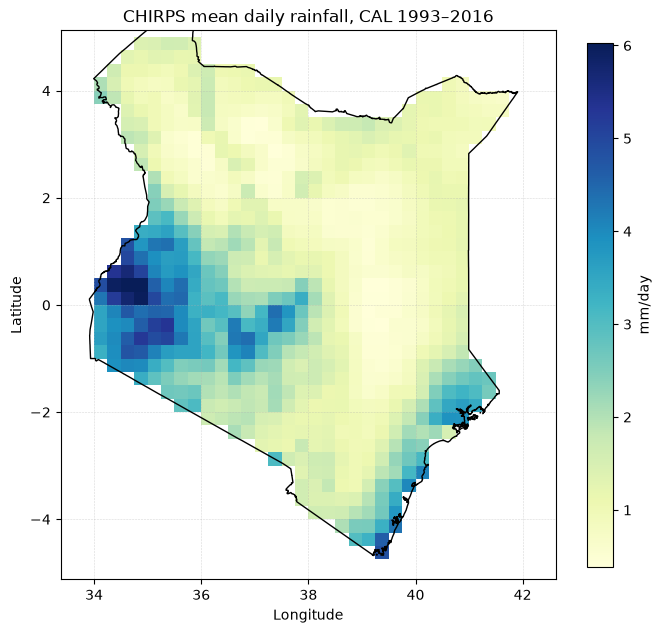

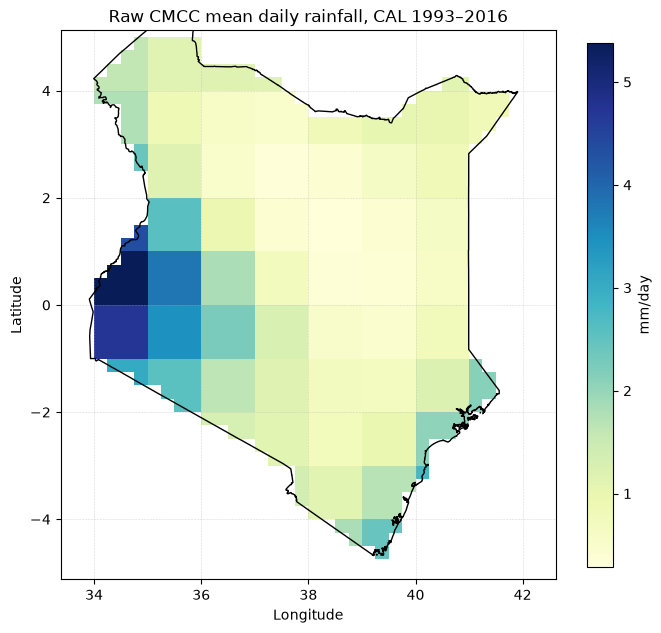

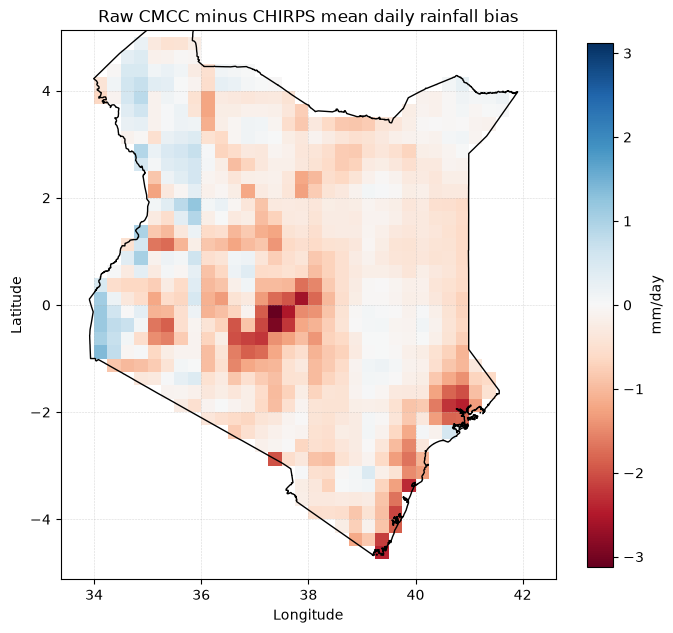

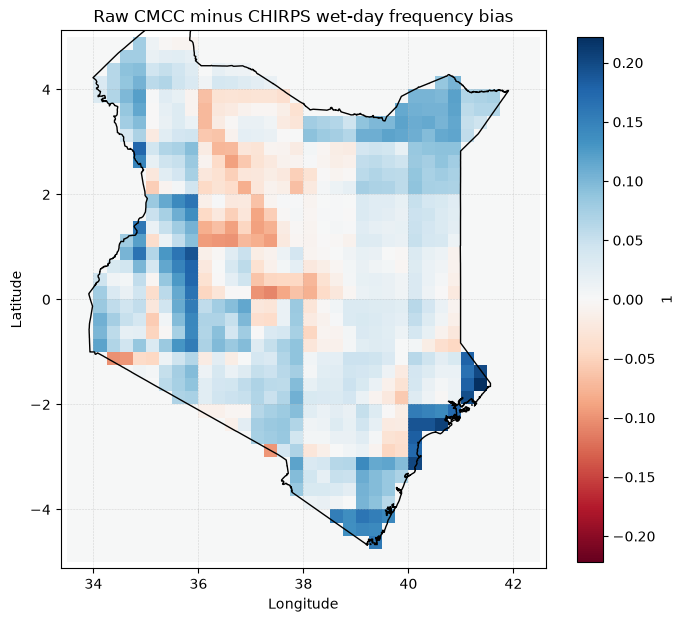

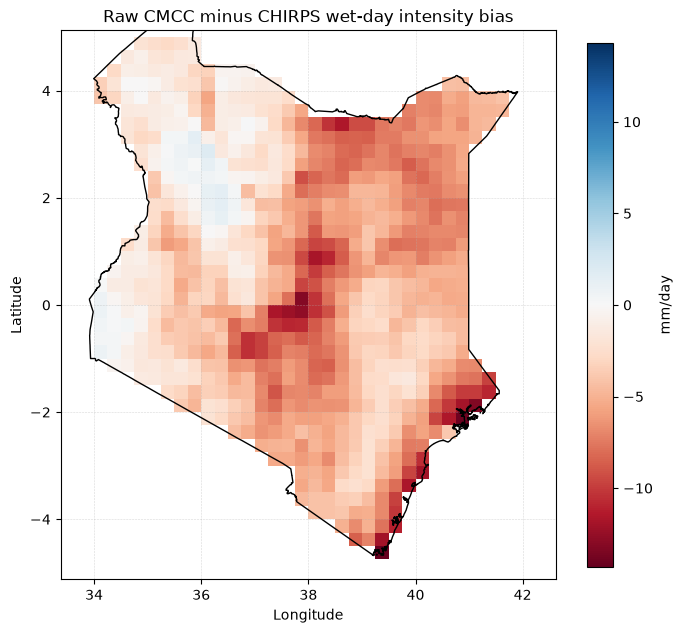

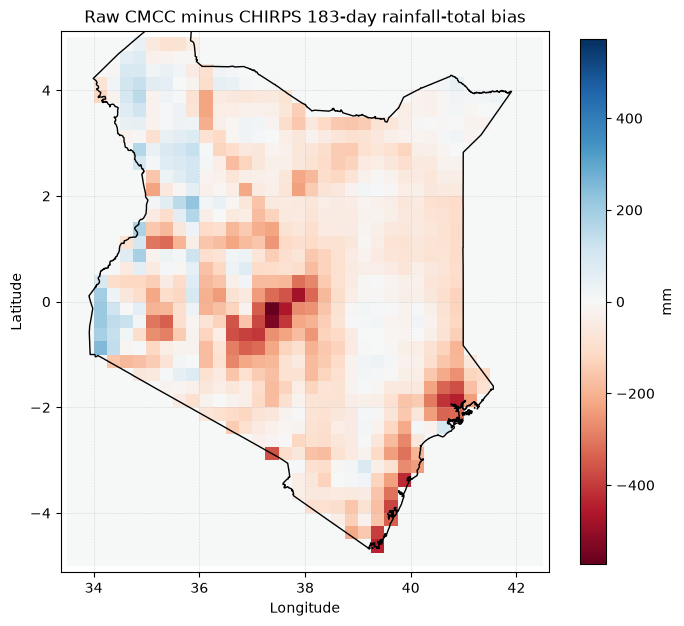

In [39]:
# =============================================================================
# 23G. PRE-BIAS-CORRECTION SPATIAL DIAGNOSTIC MAPS — SAFE VERSION
# =============================================================================

logger.info("Stage 23G: Plotting pre-bias-correction spatial diagnostics safely")

PRE_BC_PLOT_DIR = OUTPUTS.plots / "pre_bias_correction"
PRE_BC_PLOT_DIR.mkdir(parents=True, exist_ok=True)


def clean_geometries_for_plotting(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Clean geometries to avoid GEOS/cartopy plotting errors.

    This handles invalid polygons, unclosed rings, and geometry collections.
    """
    gdf = gdf.copy()

    if gdf.crs is None:
        logger.warning("Kenya shapefile CRS missing. Assuming EPSG:4326.")
        gdf = gdf.set_crs("EPSG:4326")

    gdf = gdf.to_crs("EPSG:4326")

    # Try shapely make_valid first
    try:
        from shapely.validation import make_valid
        gdf["geometry"] = gdf.geometry.apply(
            lambda geom: make_valid(geom) if geom is not None else geom
        )
    except Exception:
        logger.warning("shapely.make_valid unavailable. Using buffer(0) fallback.")
        gdf["geometry"] = gdf.geometry.buffer(0)

    # Remove empty/null geometries
    gdf = gdf.loc[gdf.geometry.notnull()].copy()
    gdf = gdf.loc[~gdf.geometry.is_empty].copy()

    # Explode multipart geometries
    try:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    except TypeError:
        gdf = gdf.explode().reset_index(drop=True)

    # Final buffer(0) cleanup
    try:
        gdf["geometry"] = gdf.geometry.buffer(0)
    except Exception:
        pass

    gdf = gdf.loc[gdf.geometry.notnull()].copy()
    gdf = gdf.loc[~gdf.geometry.is_empty].copy()

    return gdf


kenya_gdf_clean = gpd.read_file(INPUTS.kenya_shp)
kenya_gdf_clean = clean_geometries_for_plotting(kenya_gdf_clean)

logger.info("Cleaned Kenya geometries for plotting: %d feature(s)", len(kenya_gdf_clean))


def get_plot_extent_from_data(
    da: xr.DataArray,
    padding: float = 0.25,
) -> Tuple[float, float, float, float]:
    """
    Get lon/lat extent from a DataArray.
    """
    lon_min = float(da["lon"].min()) - padding
    lon_max = float(da["lon"].max()) + padding
    lat_min = float(da["lat"].min()) - padding
    lat_max = float(da["lat"].max()) + padding

    return lon_min, lon_max, lat_min, lat_max


def compute_symmetric_limits(data: xr.DataArray) -> Tuple[float, float]:
    """
    Compute symmetric plotting limits around zero.
    """
    arr = data.values

    if hasattr(data.data, "compute"):
        arr = data.compute().values

    absmax = np.nanmax(np.abs(arr))

    if not np.isfinite(absmax) or absmax == 0:
        absmax = 1.0

    return -float(absmax), float(absmax)


def plot_spatial_diagnostic_safe(
    da: xr.DataArray,
    title: str,
    output_path: Union[str, Path],
    cmap: str = "viridis",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    center_zero: bool = False,
) -> Path:
    """
    Plot one spatial diagnostic map without Cartopy.

    This avoids GEOSException caused by Cartopy/Shapely geometry rendering.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    data = da.compute() if hasattr(da.data, "compute") else da

    if center_zero:
        vmin, vmax = compute_symmetric_limits(data)

    lon_min, lon_max, lat_min, lat_max = get_plot_extent_from_data(data)

    fig, ax = plt.subplots(figsize=(7, 7))

    mesh = ax.pcolormesh(
        data["lon"].values,
        data["lat"].values,
        data.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )

    # Plot cleaned Kenya boundary
    kenya_gdf_clean.boundary.plot(
        ax=ax,
        edgecolor="black",
        linewidth=1.0,
    )

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.4,
        alpha=0.5,
    )

    cbar = fig.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.8)
    cbar.set_label(da.attrs.get("units", ""))

    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    #plt.close(fig)

    logger.info("Saved map: %s", output_path)

    return output_path


plot_spatial_diagnostic_safe(
    ds_pre_bc_diag["chirps_mean_pr"],
    "CHIRPS mean daily rainfall, CAL 1993–2016",
    PRE_BC_PLOT_DIR / "chirps_mean_daily_pr_cal_1993_2016.png",
    cmap="YlGnBu",
)

plot_spatial_diagnostic_safe(
    ds_pre_bc_diag["cmcc_mean_pr"],
    "Raw CMCC mean daily rainfall, CAL 1993–2016",
    PRE_BC_PLOT_DIR / "cmcc_raw_mean_daily_pr_cal_1993_2016.png",
    cmap="YlGnBu",
)

plot_spatial_diagnostic_safe(
    ds_pre_bc_diag["mean_pr_bias"],
    "Raw CMCC minus CHIRPS mean daily rainfall bias",
    PRE_BC_PLOT_DIR / "cmcc_minus_chirps_mean_daily_pr_bias_cal_1993_2016.png",
    cmap="RdBu",
    center_zero=True,
)

plot_spatial_diagnostic_safe(
    ds_pre_bc_diag["wet_day_frequency_bias"],
    "Raw CMCC minus CHIRPS wet-day frequency bias",
    PRE_BC_PLOT_DIR / "cmcc_minus_chirps_wet_day_frequency_bias_cal_1993_2016.png",
    cmap="RdBu",
    center_zero=True,
)

plot_spatial_diagnostic_safe(
    ds_pre_bc_diag["wet_day_intensity_bias"],
    "Raw CMCC minus CHIRPS wet-day intensity bias",
    PRE_BC_PLOT_DIR / "cmcc_minus_chirps_wet_day_intensity_bias_cal_1993_2016.png",
    cmap="RdBu",
    center_zero=True,
)

plot_spatial_diagnostic_safe(
    ds_pre_bc_diag["seasonal_total_bias"],
    "Raw CMCC minus CHIRPS 183-day rainfall-total bias",
    PRE_BC_PLOT_DIR / "cmcc_minus_chirps_183day_total_bias_cal_1993_2016.png",
    cmap="RdBu",
    center_zero=True,
)

logger.info("Pre-bias-correction spatial diagnostic maps completed safely.")

## FINAL CHECKLIST BEFORE BIAS CORRECTION

In [43]:
# =============================================================================
# =============================================================================

final_check_rows = []

def add_final_check(name: str, passed: bool, detail: str) -> None:
    final_check_rows.append(
        {
            "stage": name,
            "passed": bool(passed),
            "detail": detail,
        }
    )


add_final_check(
    "1. CMCC regridded to CHIRPS 0.25° grid",
    bool(
        np.allclose(ds_cmcc_regridded_daily["lat"].values, ds_chirps_matching_daily["lat"].values)
        and np.allclose(ds_cmcc_regridded_daily["lon"].values, ds_chirps_matching_daily["lon"].values)
    ),
    f"target grid = {ds_cmcc_regridded_daily.sizes['lat']} x {ds_cmcc_regridded_daily.sizes['lon']}",
)

add_final_check(
    "1b. Conservative + area-weighted regridding confirmed",
    "conservative" in str(regridding_method_attr).lower() and weights_file_conservative.exists(),
    f"method={regridding_method_attr}; weights={weights_file_conservative.exists()}",
)

add_final_check(
    "2. Time and lead dimensions aligned",
    bool(
        np.array_equal(
            ds_cmcc_regridded_daily["lead_day"].values,
            ds_chirps_matching_daily["lead_day"].values,
        )
        and ds_cmcc_regridded_daily.sizes["lead_day"] == 183
    ),
    f"lead_day={ds_cmcc_regridded_daily.sizes['lead_day']}",
)

add_final_check(
    "3. Kenya mask applied",
    bool(mask_check_df["passed"].all()),
    f"inside cells={int(kenya_mask.sum().values)}",
)

add_final_check(
    "4. Pre-bias-correction diagnostics created",
    Path(OUT_PRE_BC_DIAG).exists(),
    str(OUT_PRE_BC_DIAG),
)

add_final_check(
    "4b. Area-weighted pre-bias summary created",
    Path(OUT_PRE_BC_SUMMARY).exists(),
    str(OUT_PRE_BC_SUMMARY),
)

add_final_check(
    "4c. Spatial diagnostic maps created",
    len(list(PRE_BC_PLOT_DIR.glob("*.png"))) >= 6,
    f"n_maps={len(list(PRE_BC_PLOT_DIR.glob('*.png')))}; directory={PRE_BC_PLOT_DIR}",
)

final_check_df = pd.DataFrame(final_check_rows)

OUT_STAGE23_FINAL_CHECK = OUTPUTS.manifests / "stage23_pre_bias_correction_final_checklist.csv"
final_check_df.to_csv(OUT_STAGE23_FINAL_CHECK, index=False)

display(final_check_df)

if not final_check_df["passed"].all():
    logger.warning(
        "Some Stage 23 checks did not pass. Review the checklist before bias correction."
    )
else:
    logger.info("All Stage 23 checks passed. Ready for daily bias correction.")

logger.info("Wrote Stage 23 final checklist: %s", OUT_STAGE23_FINAL_CHECK)

,stage,passed,detail
0,1. CMCC regridded to CHIRPS 0.25° grid,True,target grid = 40 x 36
1,1b. Conservative + area-weighted regridding co...,True,method=xESMF conservative; weights=True
2,2. Time and lead dimensions aligned,True,lead_day=183
3,3. Kenya mask applied,True,inside cells=763
4,4. Pre-bias-correction diagnostics created,True,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\diagn...
5,4b. Area-weighted pre-bias summary created,True,D:\dashboard_ons_cess_sl\outputs\cmcc_v1\diagn...
6,4c. Spatial diagnostic maps created,True,n_maps=6; directory=D:\dashboard_ons_cess_sl\o...


2026-06-16 11:01:28 | INFO     | All Stage 23 checks passed. Ready for daily bias correction.
2026-06-16 11:01:28 | INFO     | Wrote Stage 23 final checklist: D:\dashboard_ons_cess_sl\outputs\cmcc_v1\manifests\stage23_pre_bias_correction_final_checklist.csv


In [44]:
# =============================================================================
# VERIFY CHIRPS MATCHING DATE WINDOW LENGTH
# =============================================================================

date_window_rows = []

for year in ds_chirps_matching_daily["year"].values.astype(int):
    obs_dates = pd.to_datetime(
        ds_chirps_matching_daily["chirps_obs_date"].sel(year=year).values
    )

    cmcc_valid = pd.to_datetime(
        ds_chirps_matching_daily["cmcc_valid_time"].sel(year=year).values
    )

    n_days = len(obs_dates)
    expected_n_days = 183

    date_window_rows.append(
        {
            "year": int(year),
            "first_chirps_obs_date": str(pd.Timestamp(obs_dates[0]).date()),
            "last_chirps_obs_date": str(pd.Timestamp(obs_dates[-1]).date()),
            "first_cmcc_valid_time": str(pd.Timestamp(cmcc_valid[0]).date()),
            "last_cmcc_valid_time": str(pd.Timestamp(cmcc_valid[-1]).date()),
            "n_matched_days": n_days,
            "passed": n_days == expected_n_days,
        }
    )

date_window_df = pd.DataFrame(date_window_rows)

display(date_window_df)

if not date_window_df["passed"].all():
    raise RuntimeError("Some years do not have exactly 183 matched CHIRPS rainfall days.")

logger.info("All CHIRPS-CMCC matched date windows contain 183 rainfall days.")

,year,first_chirps_obs_date,last_chirps_obs_date,first_cmcc_valid_time,last_cmcc_valid_time,n_matched_days,passed
0,1993,1993-02-01,1993-08-02,1993-02-02,1993-08-03,183,True
1,1994,1994-02-01,1994-08-02,1994-02-02,1994-08-03,183,True
2,1995,1995-02-01,1995-08-02,1995-02-02,1995-08-03,183,True
3,1996,1996-02-01,1996-08-01,1996-02-02,1996-08-02,183,True
4,1997,1997-02-01,1997-08-02,1997-02-02,1997-08-03,183,True
5,1998,1998-02-01,1998-08-02,1998-02-02,1998-08-03,183,True
6,1999,1999-02-01,1999-08-02,1999-02-02,1999-08-03,183,True
7,2000,2000-02-01,2000-08-01,2000-02-02,2000-08-02,183,True
8,2001,2001-02-01,2001-08-02,2001-02-02,2001-08-03,183,True
9,2002,2002-02-01,2002-08-02,2002-02-02,2002-08-03,183,True


2026-06-16 11:18:21 | INFO     | All CHIRPS-CMCC matched date windows contain 183 rainfall days.
